# AgriProcure — Model Experimentation Notebook

This notebook documents the predictive modeling phase for the AgriProcure project. The goal is to forecast next-week wholesale price movements for key perishable commodities (**Tomato**, **Onion**, **Potato**) across Agricultural Produce Market Committees (mandis) in India.

The primary task is **3-class classification** predicting whether next week's wholesale price will rise, fall, or stay flat relative to the current week:
- **`fall`**: next-week price change $< -2.5\%$
- **`flat`**: next-week price change between $-2.5\%$ and $+2.5\%$
- **`rise`**: next-week price change $> +2.5\%$

---

## Experiment 0 — Modeling Setup & Leakage Validation

Before training baseline or machine learning models, this experiment validates the integrity of our dataset, verifies target consistency and chronological partitions, defines feature sets and exclusions, audits potential data leakage risks, inspects structural time-series patterns, and formalizes an expanding-window rolling-origin cross-validation strategy.

## Load Modeling Data

We load the primary panel dataset (`data/features_panel.csv`) and the PCA-transformed dataset (`data/features_pca.csv`). We also parse the timestamps and separate the official chronological training and test splits.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Formatting and visualization settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

# Load primary feature panel and PCA dataset
data_path = os.path.join('..', 'data', 'features_panel.csv')
pca_path = os.path.join('..', 'data', 'features_pca.csv')
pca_model_path = os.path.join('..', 'models', 'pca_pipeline.joblib')

df = pd.read_csv(data_path)
df['week_start_date'] = pd.to_datetime(df['week_start_date'])

df_pca = pd.read_csv(pca_path)
df_pca['week_start_date'] = pd.to_datetime(df_pca['week_start_date'])

train_df = df[df['split'] == 'train'].copy()
test_df = df[df['split'] == 'test'].copy()

## Dataset & Chronological Split Overview

The primary dataset contains weekly panel observations across mandi-crop pairs. The partition into training and test sets is strictly chronological, preserving a forward-looking test holdout.

In [2]:
summary_metrics = {
    'Metric': [
        'Total rows',
        'Total columns',
        'Training rows',
        'Test rows',
        'Training start date',
        'Training end date',
        'Test start date',
        'Test end date',
        'Total unique weeks',
        'Training weeks',
        'Test weeks',
        'Chronological order valid'
    ],
    'Value': [
        len(df),
        df.shape[1],
        len(train_df),
        len(test_df),
        train_df['week_start_date'].min().strftime('%Y-%m-%d'),
        train_df['week_start_date'].max().strftime('%Y-%m-%d'),
        test_df['week_start_date'].min().strftime('%Y-%m-%d'),
        test_df['week_start_date'].max().strftime('%Y-%m-%d'),
        df['week_start_date'].nunique(),
        train_df['week_start_date'].nunique(),
        test_df['week_start_date'].nunique(),
        bool(test_df['week_start_date'].min() > train_df['week_start_date'].max())
    ]
}

summary_table = pd.DataFrame(summary_metrics)
display(summary_table)

,Metric,Value
0,Total rows,9030
1,Total columns,46
2,Training rows,6720
3,Test rows,2310
4,Training start date,2025-11-24
5,Training end date,2026-06-29
6,Test start date,2026-07-06
7,Test end date,2026-09-14
8,Total unique weeks,43
9,Training weeks,32


The training and test partitions cover non-overlapping chronological periods, preserving a pure out-of-time evaluation block that will remain quarantined until final model evaluation.

## Target Verification

The classification target is `target_direction` (`fall`, `flat`, `rise`), which is derived from the percentage change in wholesale price over the next week (`target_pct_change`). We verify that class labels strictly match the agreed threshold rules.

In [3]:
def check_expected_class(pct):
    if pct < -2.5:
        return 'fall'
    elif pct > 2.5:
        return 'rise'
    else:
        return 'flat'

df_target_check = df[['target_direction', 'target_pct_change']].copy()
df_target_check['expected'] = df_target_check['target_pct_change'].apply(check_expected_class)

target_validation = []
for label, rule in [('fall', 'target_pct_change < -2.5%'),
                    ('flat', '-2.5% <= target_pct_change <= 2.5%'),
                    ('rise', 'target_pct_change > 2.5%')]:
    sub = df_target_check[df_target_check['target_direction'] == label]
    mismatches = (sub['expected'] != label).sum()
    target_validation.append({
        'Class': label,
        'Expected Rule': rule,
        'Actual Count': len(sub),
        'Mismatch Count': mismatches
    })

target_validation_df = pd.DataFrame(target_validation)
display(target_validation_df)

,Class,Expected Rule,Actual Count,Mismatch Count
0,fall,target_pct_change < -2.5%,2772,0
1,flat,-2.5% <= target_pct_change <= 2.5%,2987,0
2,rise,target_pct_change > 2.5%,3271,0


The labels in `target_direction` match the continuous percentage price change threshold rules with zero mismatches across all rows.

## Class Distribution

We inspect how the target classes are distributed across the overall dataset, the training period, and the test holdout.

In [4]:
train_counts = train_df['target_direction'].value_counts()
train_pcts = (train_df['target_direction'].value_counts(normalize=True) * 100).round(2)

test_counts = test_df['target_direction'].value_counts()
test_pcts = (test_df['target_direction'].value_counts(normalize=True) * 100).round(2)

class_dist_df = pd.DataFrame({
    'Train Count': train_counts,
    'Train %': train_pcts,
    'Test Count': test_counts,
    'Test %': test_pcts
})
class_dist_df.index.name = 'Class'
display(class_dist_df)

,Train Count,Train %,Test Count,Test %
Class,,,,
fall,2192,32.62,580,25.11
flat,2173,32.34,814,35.24
rise,2355,35.04,916,39.65


The class distribution is reasonably represented across the three target classes, although the proportions are not identical. The displayed train/test distributions are used to assess whether class imbalance or distribution shift may affect model evaluation.

## Feature Setup & Exclusions

We organize the 46 columns in `features_panel.csv` into functional groups and explicitly quarantine identifiers and target variables from model inputs.

In [5]:
PRICE_FEATURES = [
    'price', 'price_lag_1', 'price_lag_2', 'price_lag_4',
    'pct_change_1w', 'pct_change_2w', 'pct_change_4w',
    'roll_mean_4', 'roll_mean_8', 'price_vs_roll_mean_4',
    'price_vs_roll_mean_8', 'roll_std_4', 'price_spread_pct',
    'price_vs_state_mean', 'price_vs_national_mean'
]

ARRIVALS_FEATURES = [
    'arrivals', 'arrivals_lag_1', 'arrivals_pct_change_1w',
    'arrivals_roll_mean_4', 'arrivals_vs_roll_mean_4'
]

WEATHER_FEATURES = [
    'rainfall_mm', 'rainfall_lag_1', 'rainfall_lag_2',
    'rainfall_roll_sum_4', 'rainy_days', 'heavy_rain_flag',
    'temp_mean_c', 'temp_max_c', 'heat_flag', 'temp_anomaly_c',
    'humidity_mean_pct', 'humidity_roll_mean_4'
]

CALENDAR_FEATURES = [
    'week_of_quarter', 'next_week_is_quarter_start', 'quarter',
    'month', 'week_of_year_sin', 'week_of_year_cos'
]

CATEGORICAL_FEATURES = ['crop', 'state']
EXCLUDED_COLUMNS = ['district', 'market_name', 'week_start_date', 'split', 'target_pct_change', 'target_direction']

ALL_NUMERICAL_FEATURES = PRICE_FEATURES + ARRIVALS_FEATURES + WEATHER_FEATURES + CALENDAR_FEATURES
PREDICTOR_FEATURES = ALL_NUMERICAL_FEATURES + CATEGORICAL_FEATURES

feature_summary_df = pd.DataFrame([
    {'Group': 'Price Features', 'Count': len(PRICE_FEATURES), 'Predictor': True, 'Examples': 'price, price_lag_1, roll_mean_4, price_vs_roll_mean_8'},
    {'Group': 'Arrivals Features', 'Count': len(ARRIVALS_FEATURES), 'Predictor': True, 'Examples': 'arrivals, arrivals_lag_1, arrivals_pct_change_1w'},
    {'Group': 'Weather Features', 'Count': len(WEATHER_FEATURES), 'Predictor': True, 'Examples': 'rainfall_mm, rainfall_roll_sum_4, temp_mean_c, heat_flag'},
    {'Group': 'Calendar Features', 'Count': len(CALENDAR_FEATURES), 'Predictor': True, 'Examples': 'week_of_quarter, next_week_is_quarter_start, quarter, month'},
    {'Group': 'Categorical Features', 'Count': len(CATEGORICAL_FEATURES), 'Predictor': True, 'Examples': 'crop, state'},
    {'Group': 'Excluded Identifiers', 'Count': 4, 'Predictor': False, 'Examples': 'market_name, district, week_start_date, split'},
    {'Group': 'Target Columns', 'Count': 2, 'Predictor': False, 'Examples': 'target_direction, target_pct_change'}
])

display(feature_summary_df)

,Group,Count,Predictor,Examples
0,Price Features,15,True,"price, price_lag_1, roll_mean_4, price_vs_roll..."
1,Arrivals Features,5,True,"arrivals, arrivals_lag_1, arrivals_pct_change_1w"
2,Weather Features,12,True,"rainfall_mm, rainfall_roll_sum_4, temp_mean_c,..."
3,Calendar Features,6,True,"week_of_quarter, next_week_is_quarter_start, q..."
4,Categorical Features,2,True,"crop, state"
5,Excluded Identifiers,4,False,"market_name, district, week_start_date, split"
6,Target Columns,2,False,"target_direction, target_pct_change"


`market_name` and `district` are excluded from the predictor matrix because high-cardinality market identifiers with limited temporal observations per series introduce high variance and risk of memorization. `crop` and `state` are retained for categorical encoding.

## Data Quality Checks

We verify that the primary modeling panel contains no missing values, infinite values, or duplicate records.

In [6]:
num_numeric = df[ALL_NUMERICAL_FEATURES].select_dtypes(include=[np.number])

data_quality_df = pd.DataFrame([
    {'Check': 'Missing cells across all 46 columns', 'Count': int(df.isnull().sum().sum())},
    {'Check': 'Infinite values across numerical features', 'Count': int(np.isinf(num_numeric.to_numpy()).sum())},
    {'Check': 'Exact duplicate rows', 'Count': int(df.duplicated().sum())},
    {'Check': 'Duplicate panel-week keys (market x crop x week)', 'Count': int(df.duplicated(subset=['market_name', 'crop', 'week_start_date']).sum())}
])

display(data_quality_df)

,Check,Count
0,Missing cells across all 46 columns,0
1,Infinite values across numerical features,0
2,Exact duplicate rows,0
3,Duplicate panel-week keys (market x crop x week),0


## Panel Series Integrity

We verify that each individual market-crop series has full temporal coverage across both training and test partitions.

In [7]:
n_markets = df['market_name'].nunique()
n_crops = df['crop'].nunique()
expected_series_count = n_markets * n_crops

total_unique_weeks = df['week_start_date'].nunique()
train_unique_weeks = train_df['week_start_date'].nunique()
test_unique_weeks = test_df['week_start_date'].nunique()

series_lengths = df.groupby(['market_name', 'crop'])['week_start_date'].count()
train_series_lengths = train_df.groupby(['market_name', 'crop'])['week_start_date'].count()
test_series_lengths = test_df.groupby(['market_name', 'crop'])['week_start_date'].count()

panel_integrity_df = pd.DataFrame([
    {'Metric': 'Unique markets (mandis)', 'Value': n_markets},
    {'Metric': 'Unique crops', 'Value': n_crops},
    {'Metric': 'Expected series count (markets x crops)', 'Value': expected_series_count},
    {'Metric': 'Actual unique market-crop series', 'Value': len(series_lengths)},
    {'Metric': 'Total unique weeks in dataset', 'Value': total_unique_weeks},
    {'Metric': 'Total observations per series (min / max)', 'Value': f"{series_lengths.min()} / {series_lengths.max()}"},
    {'Metric': 'Training observations per series (min / max)', 'Value': f"{train_series_lengths.min()} / {train_series_lengths.max()}"},
    {'Metric': 'Test observations per series (min / max)', 'Value': f"{test_series_lengths.min()} / {test_series_lengths.max()}"},
    {'Metric': 'Balanced panel (all series complete)', 'Value': bool((series_lengths == total_unique_weeks).all())}
])

display(panel_integrity_df)

,Metric,Value
0,Unique markets (mandis),70
1,Unique crops,3
2,Expected series count (markets x crops),210
3,Actual unique market-crop series,210
4,Total unique weeks in dataset,43
5,Total observations per series (min / max),43 / 43
6,Training observations per series (min / max),32 / 32
7,Test observations per series (min / max),11 / 11
8,Balanced panel (all series complete),True


## Leakage Checks & Modeling Caveats

We check that no target columns, raw dates, or partition labels are passed to model predictors, and that chronological ordering is strictly preserved.

In [8]:
leakage_checks = [
    ('Target columns excluded from X', bool('target_direction' not in PREDICTOR_FEATURES and 'target_pct_change' not in PREDICTOR_FEATURES)),
    ('Identifier columns excluded from X', bool(all(col not in PREDICTOR_FEATURES for col in ['district', 'market_name']))),
    ('Partition and timestamp columns excluded from X', bool('split' not in PREDICTOR_FEATURES and 'week_start_date' not in PREDICTOR_FEATURES)),
    ('Test partition strictly follows training partition', bool(test_df['week_start_date'].min() > train_df['week_start_date'].max())),
    ('Zero missing values in modeling matrix', bool(df[PREDICTOR_FEATURES].isnull().sum().sum() == 0)),
    ('Zero duplicate panel observations', bool(df.duplicated(subset=['market_name', 'crop', 'week_start_date']).sum() == 0))
]

leakage_check_df = pd.DataFrame(leakage_checks, columns=['Check', 'Result'])
display(leakage_check_df)

,Check,Result
0,Target columns excluded from X,True
1,Identifier columns excluded from X,True
2,Partition and timestamp columns excluded from X,True
3,Test partition strictly follows training parti...,True
4,Zero missing values in modeling matrix,True
5,Zero duplicate panel observations,True


No direct target-column leakage was found in the modeling matrix. The feature construction audit indicates that the engineered temporal features are backward-looking (using trailing lags $t-1 \dots t-k$) or based on calendar information available at prediction time.

**Modeling Caveat on Cross-Sectional Features:**  
`price_vs_state_mean` and `price_vs_national_mean` use contemporaneous cross-sectional averages across mandis for the current week $t$. For the purposes of this capstone, this is acceptable under the assumption that all mandis report on a weekly cadence. However, in a real-time production setting where reporting delays vary by market, these features would need to be lagged ($t-1$) to ensure complete reporting availability.

## Data Pattern Diagnostic

Prior exploratory analysis identified a pronounced quarterly sawtooth pattern in price trajectories across all mandis. We visualize this pattern across crops and calculate the degree of cross-series synchronization.

,Metric,Value
0,Mean pairwise price correlation across series,0.5109
1,Median pairwise price correlation,0.5176
2,Min / Max pairwise correlation,0.0426 / 0.8566
3,Average cross-sectional Coefficient of Variati...,0.1810
4,Number of quarter-boundary reset weeks in time...,3


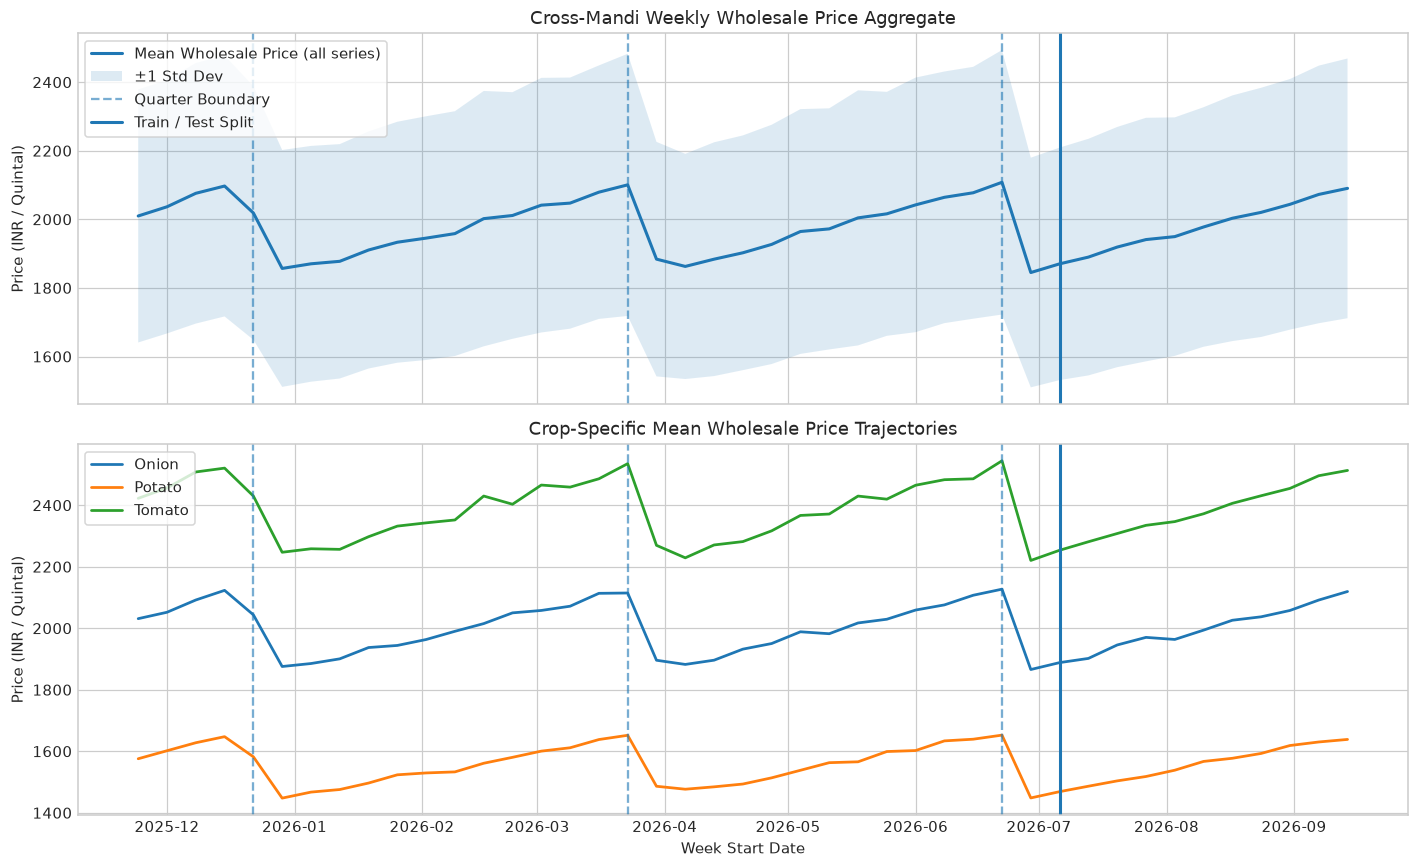

In [9]:
# Weekly aggregate price
weekly_price = df.groupby('week_start_date')['price'].agg(['mean', 'std']).reset_index()
weekly_price['cv'] = weekly_price['std'] / weekly_price['mean']

# Cross-series correlation matrix across all series
price_pivot = df.pivot_table(index='week_start_date', columns=['crop', 'market_name'], values='price')
corr_matrix = price_pivot.corr()
triu_idx = np.triu_indices_from(corr_matrix.values, k=1)
pairwise_corrs = corr_matrix.values[triu_idx]

# Dynamically identify quarter boundary weeks where next_week_is_quarter_start == 1
quarter_boundary_weeks = df[df['next_week_is_quarter_start'] == 1]['week_start_date'].unique()
test_start_date = test_df['week_start_date'].min()

# Diagnostic summary table
diagnostic_summary = pd.DataFrame([
    {'Metric': 'Mean pairwise price correlation across series', 'Value': f"{np.mean(pairwise_corrs):.4f}"},
    {'Metric': 'Median pairwise price correlation', 'Value': f"{np.median(pairwise_corrs):.4f}"},
    {'Metric': 'Min / Max pairwise correlation', 'Value': f"{np.min(pairwise_corrs):.4f} / {np.max(pairwise_corrs):.4f}"},
    {'Metric': 'Average cross-sectional Coefficient of Variation (CV)', 'Value': f"{weekly_price['cv'].mean():.4f}"},
    {'Metric': 'Number of quarter-boundary reset weeks in timeline', 'Value': len(quarter_boundary_weeks)}
])
display(diagnostic_summary)

# Plotting weekly trends
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# 1. Overall mean wholesale price
ax1.plot(weekly_price['week_start_date'], weekly_price['mean'], lw=2, label='Mean Wholesale Price (all series)')
ax1.fill_between(weekly_price['week_start_date'], 
                 weekly_price['mean'] - weekly_price['std'], 
                 weekly_price['mean'] + weekly_price['std'], 
                 alpha=0.15, label='±1 Std Dev')

for qb in quarter_boundary_weeks:
    ax1.axvline(qb, linestyle='--', alpha=0.6, label='Quarter Boundary' if qb == quarter_boundary_weeks[0] else "")

ax1.axvline(test_start_date, linestyle='-', lw=2, label='Train / Test Split')
ax1.set_ylabel('Price (INR / Quintal)')
ax1.set_title('Cross-Mandi Weekly Wholesale Price Aggregate')
ax1.legend(loc='upper left', frameon=True)

# 2. Crop-specific trajectories
for crop_name in df['crop'].unique():
    crop_mean = df[df['crop'] == crop_name].groupby('week_start_date')['price'].mean()
    ax2.plot(crop_mean.index, crop_mean.values, lw=1.8, label=crop_name)

for qb in quarter_boundary_weeks:
    ax2.axvline(qb, linestyle='--', alpha=0.6)
ax2.axvline(test_start_date, linestyle='-', lw=2)

ax2.set_xlabel('Week Start Date')
ax2.set_ylabel('Price (INR / Quintal)')
ax2.set_title('Crop-Specific Mean Wholesale Price Trajectories')
ax2.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

The synchronized movement diagnostic is useful for identifying common temporal patterns across series. A high cross-series similarity would suggest that part of the apparent price movement is shared across markets rather than being purely market-specific. Quarter-boundary indicators are retained as candidate predictors and will be evaluated empirically during model experiments.

## Feature Correlation with Next-Week Price Change

We examine the linear correlation between each numerical feature and `target_pct_change` on the training partition.

In [10]:
train_numeric = train_df[ALL_NUMERICAL_FEATURES]
corrs = train_numeric.apply(lambda col: col.corr(train_df['target_pct_change']))

top_corrs_df = pd.DataFrame({
    'Feature': corrs.index,
    'Correlation with target_pct_change': corrs.values,
    'Absolute Correlation': np.abs(corrs.values)
}).sort_values(by='Absolute Correlation', ascending=False).reset_index(drop=True)

display(top_corrs_df.head(10)[['Feature', 'Correlation with target_pct_change']])

,Feature,Correlation with target_pct_change
0,next_week_is_quarter_start,-0.498793
1,price_vs_roll_mean_8,-0.436946
2,price_vs_roll_mean_4,-0.394799
3,price_vs_national_mean,-0.389810
4,price_vs_state_mean,-0.354687
5,pct_change_1w,-0.351319
6,pct_change_4w,-0.350592
7,pct_change_2w,-0.338535
8,week_of_quarter,-0.243345
9,price,-0.176396


`next_week_is_quarter_start` and ratio features like `price_vs_roll_mean_8` show the strongest negative correlation with next-week price movement, reflecting the quarter-end price resets and mean-reversion dynamics. Correlation is descriptive and does not indicate leakage; all features used here are based on information available at prediction time $t$.

## PCA Pipeline Verification

Notebook 05 generated a fitted pipeline (`models/pca_pipeline.joblib`) consisting of a `StandardScaler` and `PCA(n_components=14)`. We verify that the scaler and PCA were fitted strictly on the training partition (`split == 'train'`).

In [11]:
from sklearn.preprocessing import StandardScaler

pca_pipeline = joblib.load(pca_model_path)
scaler_step = pca_pipeline.named_steps.get('standardscaler', pca_pipeline.named_steps.get('scaler'))
pca_step = pca_pipeline.named_steps['pca']

# Retrieve the exact features passed into PCA
pca_feature_names = list(getattr(scaler_step, 'feature_names_in_', ALL_NUMERICAL_FEATURES))

# Re-fit scaler independently on train split only and compare mean vector
scaler_refit_train = StandardScaler().fit(train_df[pca_feature_names])
diff_train = float(np.max(np.abs(scaler_step.mean_ - scaler_refit_train.mean_)))

scaler_refit_all = StandardScaler().fit(df[pca_feature_names])
diff_all = float(np.max(np.abs(scaler_step.mean_ - scaler_refit_all.mean_)))

# Check transform alignment with features_pca.csv
pca_transformed = pca_pipeline.transform(df[pca_feature_names])
pca_cols = [f'PC{i+1}' for i in range(14)]
csv_pcs = df_pca[pca_cols].to_numpy()
diff_csv = float(np.max(np.abs(csv_pcs - pca_transformed)))

pca_verification_df = pd.DataFrame([
    {'Check': 'Pipeline components count', 'Value': str(pca_step.n_components_)},
    {'Check': 'Cumulative explained variance (%)', 'Value': f"{pca_step.explained_variance_ratio_.sum() * 100:.2f}%"},
    {'Check': 'Scaler difference vs train-only refit', 'Value': f"{diff_train:.2e}"},
    {'Check': 'Scaler difference vs full-dataset refit', 'Value': f"{diff_all:.2f}"},
    {'Check': 'features_pca.csv matches pipeline transform', 'Value': str(diff_csv < 1e-4)},
    {'Check': 'Fitted exclusively on train split', 'Value': str(diff_train < 1e-10)}
])

display(pca_verification_df)

,Check,Value
0,Pipeline components count,14
1,Cumulative explained variance (%),91.42%
2,Scaler difference vs train-only refit,1.69e-17
3,Scaler difference vs full-dataset refit,46.05
4,features_pca.csv matches pipeline transform,True
5,Fitted exclusively on train split,True


The PCA pipeline is checked against the saved training-fitted transformer. The displayed reconstruction error and explained-variance values provide a numerical check that the stored transformation is consistent with the modeling data.

## Rolling-Origin Validation Setup

Because this is panel time-series data, random K-Fold cross-validation would cause temporal lookahead bias. We establish an expanding-window rolling-origin cross-validation scheme within the training period.

The test partition remains quarantined until final model evaluation.

In [12]:
def get_rolling_origin_folds(df_train, initial_train_weeks=20, val_step_weeks=4, n_splits=3):
    """
    Generate chronological expanding-window train/validation indices for panel data.
    """
    sorted_weeks = np.sort(df_train['week_start_date'].unique())
    folds = []
    
    for fold_idx in range(n_splits):
        train_end_idx = initial_train_weeks + fold_idx * val_step_weeks
        val_end_idx = train_end_idx + val_step_weeks
        
        train_weeks = sorted_weeks[:train_end_idx]
        val_weeks = sorted_weeks[train_end_idx:val_end_idx]
        
        train_mask = df_train['week_start_date'].isin(train_weeks)
        val_mask = df_train['week_start_date'].isin(val_weeks)
        
        train_indices = df_train[train_mask].index.to_numpy()
        val_indices = df_train[val_mask].index.to_numpy()
        
        folds.append({
            'fold': fold_idx + 1,
            'train_weeks': train_weeks,
            'val_weeks': val_weeks,
            'train_indices': train_indices,
            'val_indices': val_indices
        })
    return folds

# Generate the 3 evaluation folds on the training set
validation_folds = get_rolling_origin_folds(train_df, initial_train_weeks=20, val_step_weeks=4, n_splits=3)

fold_summary_rows = []
for f in validation_folds:
    tr_w = f['train_weeks']
    va_w = f['val_weeks']
    fold_summary_rows.append({
        'Fold': f['fold'],
        'Train Weeks': len(tr_w),
        'Train Start': pd.to_datetime(tr_w[0]).strftime('%Y-%m-%d'),
        'Train End': pd.to_datetime(tr_w[-1]).strftime('%Y-%m-%d'),
        'Train Rows': len(f['train_indices']),
        'Val Weeks': len(va_w),
        'Val Start': pd.to_datetime(va_w[0]).strftime('%Y-%m-%d'),
        'Val End': pd.to_datetime(va_w[-1]).strftime('%Y-%m-%d'),
        'Val Rows': len(f['val_indices'])
    })

fold_summary_df = pd.DataFrame(fold_summary_rows)
display(fold_summary_df)

,Fold,Train Weeks,Train Start,Train End,Train Rows,Val Weeks,Val Start,Val End,Val Rows
0,1,20,2025-11-24,2026-04-06,4200,4,2026-04-13,2026-05-04,840
1,2,24,2025-11-24,2026-05-04,5040,4,2026-05-11,2026-06-01,840
2,3,28,2025-11-24,2026-06-01,5880,4,2026-06-08,2026-06-29,840


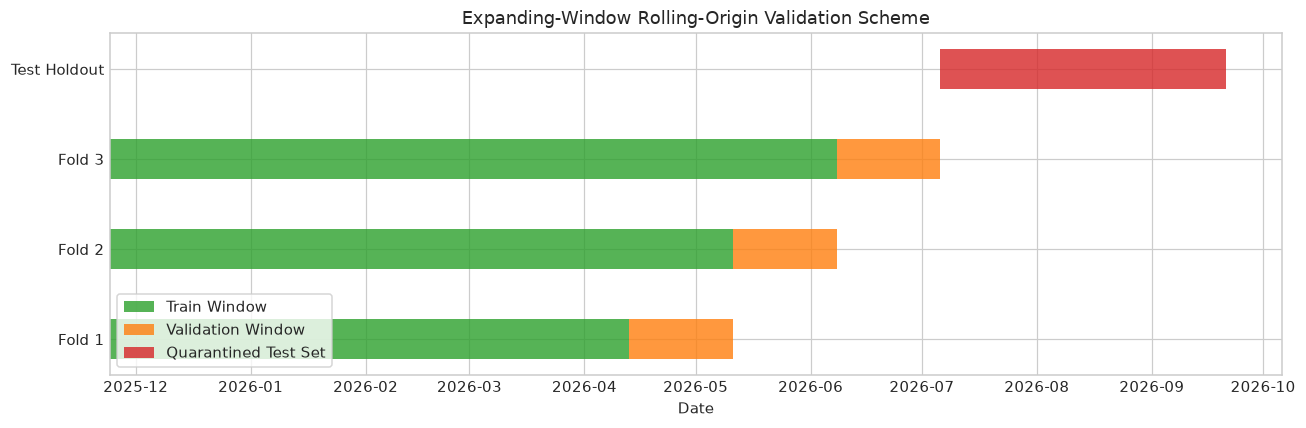

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))

for idx, row in fold_summary_df.iterrows():
    f_num = row['Fold']
    tr_s = pd.to_datetime(row['Train Start'])
    tr_e = pd.to_datetime(row['Train End'])
    va_s = pd.to_datetime(row['Val Start'])
    va_e = pd.to_datetime(row['Val End'])
    
    ax.barh(f"Fold {f_num}", (tr_e - tr_s).days + 7, left=tr_s, color='#2ca02c', alpha=0.8, height=0.45, label='Train Window' if idx == 0 else "")
    ax.barh(f"Fold {f_num}", (va_e - va_s).days + 7, left=va_s, color='#ff7f0e', alpha=0.8, height=0.45, label='Validation Window' if idx == 0 else "")

test_start = test_df['week_start_date'].min()
test_end = test_df['week_start_date'].max()
ax.barh("Test Holdout", (test_end - test_start).days + 7, left=test_start, color='#d62728', alpha=0.8, height=0.45, label='Quarantined Test Set')

ax.set_title('Expanding-Window Rolling-Origin Validation Scheme')
ax.set_xlabel('Date')
ax.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

## Experiment 0 Conclusion

Experiment 0 is complete. The modeling dataset, target, chronological split, feature exclusions, leakage checks, PCA artifact, and rolling-origin validation structure are ready for the baseline experiments.

---

## Experiment 1 — Naive & Heuristic Baselines

The purpose of naive baselines is to establish the minimum performance benchmarks that any supervised machine learning model should comfortably beat.

Because price movements in all three directions matter for procurement planning, our primary evaluation metric across all experiments is **Macro-F1**. We also monitor per-class recall for **`fall`** and **`rise`** to assess whether a model is capable of identifying actual turning points rather than defaulting to conservative predictions.

We evaluate three non-learning baselines across the rolling-origin validation folds defined in Experiment 0:
1. **Majority Class:** Always predicts the most frequent class observed in the training split of that specific fold.
2. **Always Flat:** Always predicts the `flat` (no major movement) class.
3. **Directional Persistence:** Predicts that next week's direction will match the current week's observed direction (`pct_change_1w`), applying the same $\pm 2.5\%$ threshold.

The final test set remains quarantined and untouched throughout this experiment.

In [14]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

TARGET_LABELS = ['fall', 'flat', 'rise']
fold_results = []
persistence_preds_all = []

for fold_info in validation_folds:
    f_num = fold_info['fold']
    tr_idx = fold_info['train_indices']
    val_idx = fold_info['val_indices']
    
    y_tr = train_df.loc[tr_idx, 'target_direction']
    y_val = train_df.loc[val_idx, 'target_direction']
    x_val = train_df.loc[val_idx]
    
    # 1. Majority class baseline (calculated strictly from y_train of this fold)
    fold_majority_class = y_tr.mode()[0]
    pred_majority = [fold_majority_class] * len(y_val)
    
    # 2. Always flat baseline
    pred_flat = ['flat'] * len(y_val)
    
    # 3. Directional persistence (current week's movement applied to next week)
    def map_persistence_direction(pct):
        if pct < -2.5:
            return 'fall'
        elif pct > 2.5:
            return 'rise'
        else:
            return 'flat'
            
    pred_persistence = x_val['pct_change_1w'].apply(map_persistence_direction).tolist()
    persistence_preds_all.extend(pred_persistence)
    
    candidate_baselines = [
        ('Majority Class', pred_majority),
        ('Always Flat', pred_flat),
        ('Directional Persistence', pred_persistence)
    ]
    
    for baseline_name, y_pred in candidate_baselines:
        acc = accuracy_score(y_val, y_pred)
        macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
            y_val, y_pred, average='macro', zero_division=0
        )
        p_cls, r_cls, f_cls, _ = precision_recall_fscore_support(
            y_val, y_pred, labels=TARGET_LABELS, zero_division=0
        )
        
        fold_results.append({
            'fold': f_num,
            'baseline': baseline_name,
            'accuracy': acc,
            'macro_precision': macro_p,
            'macro_recall': macro_r,
            'macro_f1': macro_f1,
            'fall_precision': p_cls[0],
            'fall_recall': r_cls[0],
            'fall_f1': f_cls[0],
            'flat_precision': p_cls[1],
            'flat_recall': r_cls[1],
            'flat_f1': f_cls[1],
            'rise_precision': p_cls[2],
            'rise_recall': r_cls[2],
            'rise_f1': f_cls[2]
        })

fold_results_df = pd.DataFrame(fold_results)

### Fold-Level Results

We review the performance across each individual expanding fold.

In [15]:
display_cols = [
    'fold', 'baseline', 'accuracy', 'macro_f1', 
    'fall_recall', 'flat_recall', 'rise_recall'
]
display(fold_results_df[display_cols].round(4))

,fold,baseline,accuracy,macro_f1,fall_recall,flat_recall,rise_recall
0,1,Majority Class,0.3952,0.1889,0.0000,0.0000,1.0000
1,1,Always Flat,0.3631,0.1776,0.0000,1.0000,0.0000
2,1,Directional Persistence,0.2595,0.2421,0.0788,0.4000,0.2410
3,2,Majority Class,0.3881,0.1864,0.0000,0.0000,1.0000
4,2,Always Flat,0.3750,0.1818,0.0000,1.0000,0.0000
5,2,Directional Persistence,0.2167,0.1981,0.0603,0.3778,0.1564
6,3,Majority Class,0.2988,0.1534,0.0000,0.0000,1.0000
7,3,Always Flat,0.2726,0.1428,0.0000,1.0000,0.0000
8,3,Directional Persistence,0.2321,0.2261,0.2750,0.3013,0.1076


### Aggregated Baseline Comparison

We aggregate the fold results across the rolling-origin validation folds to compute the mean and standard deviation of each metric, sorted by mean Macro-F1.

In [16]:
agg_baseline_results = fold_results_df.groupby('baseline').agg(
    mean_accuracy=('accuracy', 'mean'),
    std_accuracy=('accuracy', 'std'),
    mean_macro_f1=('macro_f1', 'mean'),
    std_macro_f1=('macro_f1', 'std'),
    mean_fall_recall=('fall_recall', 'mean'),
    mean_flat_recall=('flat_recall', 'mean'),
    mean_rise_recall=('rise_recall', 'mean')
).sort_values(by='mean_macro_f1', ascending=False).reset_index()

display(agg_baseline_results.round(4))

,baseline,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1,mean_fall_recall,mean_flat_recall,mean_rise_recall
0,Directional Persistence,0.2361,0.0217,0.2221,0.0223,0.138,0.3597,0.1683
1,Majority Class,0.3607,0.0537,0.1762,0.0198,0.000,0.0000,1.0000
2,Always Flat,0.3369,0.0560,0.1674,0.0214,0.000,1.0000,0.0000


### Directional Persistence Prediction Distribution

We inspect the class distribution of predictions produced by the directional persistence baseline across all validation folds.

In [17]:
pers_series = pd.Series(persistence_preds_all)
pers_dist_df = pd.DataFrame({
    'Class': pers_series.value_counts().index,
    'Count': pers_series.value_counts().values,
    'Percentage (%)': (pers_series.value_counts(normalize=True) * 100).round(2).values
})
display(pers_dist_df)

,Class,Count,Percentage (%)
0,rise,908,36.03
1,flat,848,33.65
2,fall,764,30.32


The table above shows how the directional persistence rule distributes its predictions across the three classes during validation.

### Visual Comparison of Baseline Performance

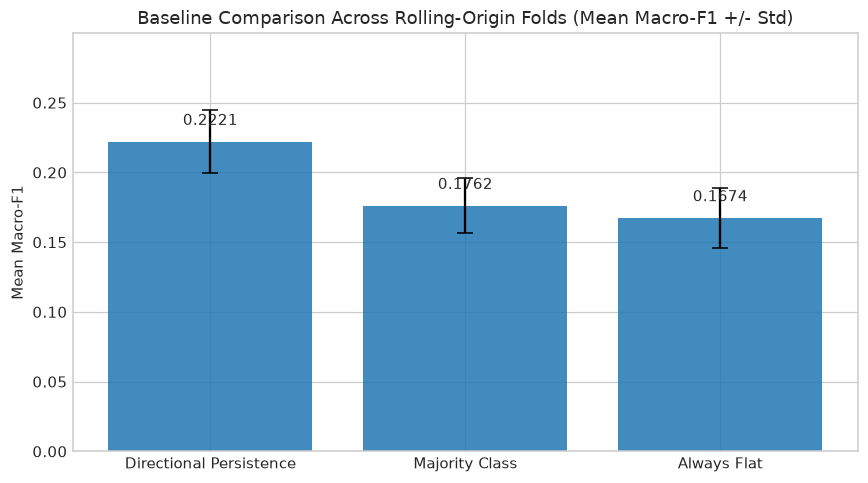

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(agg_baseline_results['baseline'], 
       agg_baseline_results['mean_macro_f1'], 
       yerr=agg_baseline_results['std_macro_f1'], 
       capsize=5, 
       alpha=0.85)

ax.set_ylabel('Mean Macro-F1')
ax.set_title('Baseline Comparison Across Rolling-Origin Folds (Mean Macro-F1 +/- Std)')
ax.set_ylim(0, max(agg_baseline_results['mean_macro_f1']) * 1.35)

for i, row in agg_baseline_results.iterrows():
    ax.text(i, row['mean_macro_f1'] + 0.012, f"{row['mean_macro_f1']:.4f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### Baseline Interpretation

The three baselines define distinct reference points for model evaluation:
- **Majority Class:** Provides a reference based on the most frequent class in each training fold.
- **Always Flat:** Represents a conservative strategy that predicts no meaningful price movement for every validation observation.
- **Directional Persistence:** Uses the current week's price movement as a simple predictor for the following week.

In [19]:
best_baseline = agg_baseline_results.iloc[0]['baseline']
best_macro_f1 = agg_baseline_results.iloc[0]['mean_macro_f1']

best_fall_row = agg_baseline_results.sort_values(by='mean_fall_recall', ascending=False).iloc[0]
best_rise_row = agg_baseline_results.sort_values(by='mean_rise_recall', ascending=False).iloc[0]

baseline_benchmark_df = pd.DataFrame([
    {'Benchmark': 'Highest Mean Macro-F1', 'Baseline': best_baseline, 'Score': f"{best_macro_f1:.4f}"},
    {'Benchmark': 'Highest Mean Fall Recall', 'Baseline': best_fall_row['baseline'], 'Score': f"{best_fall_row['mean_fall_recall']:.4f}"},
    {'Benchmark': 'Highest Mean Rise Recall', 'Baseline': best_rise_row['baseline'], 'Score': f"{best_rise_row['mean_rise_recall']:.4f}"}
])

display(baseline_benchmark_df)

,Benchmark,Baseline,Score
0,Highest Mean Macro-F1,Directional Persistence,0.2221
1,Highest Mean Fall Recall,Directional Persistence,0.1380
2,Highest Mean Rise Recall,Majority Class,1.0000


Prospective machine learning models will be compared against these baseline results to determine whether the additional modeling complexity provides a meaningful improvement.

### Save Experiment 1 Results

We save the aggregated baseline metrics to `reports/model_results.csv` and fold-level metrics to `reports/baseline_fold_results.csv` for tracking across iterations.

In [20]:
model_results_path = os.path.join('..', 'reports', 'model_results.csv')
fold_results_path = os.path.join('..', 'reports', 'baseline_fold_results.csv')

exp1_summary = agg_baseline_results.copy()
exp1_summary['experiment'] = 'Experiment 1 - Baselines'
exp1_summary = exp1_summary[['experiment', 'baseline', 'mean_accuracy', 'std_accuracy', 
                             'mean_macro_f1', 'std_macro_f1', 'mean_fall_recall', 
                             'mean_flat_recall', 'mean_rise_recall']]

if os.path.exists(model_results_path):
    existing_results = pd.read_csv(model_results_path)
    existing_results = existing_results[existing_results['experiment'] != 'Experiment 1 - Baselines']
    combined_results = pd.concat([existing_results, exp1_summary], ignore_index=True)
    combined_results.to_csv(model_results_path, index=False)
else:
    exp1_summary.to_csv(model_results_path, index=False)

fold_results_df.to_csv(fold_results_path, index=False)

saved_df = pd.read_csv(model_results_path)
display(saved_df)

,experiment,baseline,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1,mean_fall_recall,mean_flat_recall,mean_rise_recall
0,Experiment 2 - Logistic Regression,Logistic Regression,0.566667,0.042874,0.538411,0.032564,0.456993,0.416766,0.768055
1,Experiment 3 - Random Forest,Random Forest,0.564683,0.073966,0.555193,0.066187,0.635761,0.412621,0.637974
2,Experiment 4 - XGBoost,XGBoost,0.557143,0.077408,0.541526,0.076656,0.631407,0.347338,0.685246
3,Experiment 5 - LightGBM,LightGBM,0.567460,0.070754,0.551375,0.067025,0.630472,0.365848,0.689798
4,Experiment 6 - CatBoost,CatBoost,0.580159,0.081043,0.569296,0.078955,0.669638,0.408464,0.665610
5,Experiment 1 - Baselines,Directional Persistence,0.236111,0.021702,0.222116,0.022308,0.138040,0.359696,0.168325
6,Experiment 1 - Baselines,Majority Class,0.360714,0.053730,0.176206,0.019810,0.000000,0.000000,1.000000
7,Experiment 1 - Baselines,Always Flat,0.336905,0.055990,0.167405,0.021402,0.000000,1.000000,0.000000


---

## Experiment 2 — Logistic Regression

Logistic Regression provides a linear multiclass baseline and serves as our first machine learning model to compare against the naive benchmarks from Experiment 1. It models log-odds as a linear combination of features, testing whether linear decision boundaries can effectively separate wholesale price movements into `fall`, `flat`, and `rise`.

### Modeling Setup:
- **Primary Metric:** Macro-F1
- **Secondary Metrics:** `fall` recall, `rise` recall, and overall accuracy
- **Features:** 38 numerical engineered features plus categorical features (`crop`, `state`). All identifier columns (`market_name`, `district`, `week_start_date`, `split`) and target columns remain excluded.
- **Preprocessing:** Numerical features are standardized via `StandardScaler`, and categorical features are one-hot encoded via `OneHotEncoder(handle_unknown='ignore')`. The entire pipeline is fitted strictly within each training fold to avoid data leakage.
- **Validation:** Evaluated across the established rolling-origin validation folds. The final test set remains quarantined and untouched.

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

feature_cols = ALL_NUMERICAL_FEATURES + CATEGORICAL_FEATURES
lr_fold_records = []

for fold_info in validation_folds:
    f_num = fold_info['fold']
    tr_idx = fold_info['train_indices']
    val_idx = fold_info['val_indices']
    
    X_tr = train_df.loc[tr_idx, feature_cols]
    y_tr = train_df.loc[tr_idx, 'target_direction']
    X_val = train_df.loc[val_idx, feature_cols]
    y_val = train_df.loc[val_idx, 'target_direction']
    
    # Preprocessing pipeline fitted strictly on this fold's training data
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), ALL_NUMERICAL_FEATURES),
            ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES)
        ]
    )
    
    lr_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])
    
    lr_pipeline.fit(X_tr, y_tr)
    y_pred = lr_pipeline.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_val, y_pred, average='macro', zero_division=0
    )
    p_cls, r_cls, f_cls, _ = precision_recall_fscore_support(
        y_val, y_pred, labels=TARGET_LABELS, zero_division=0
    )
    
    lr_fold_records.append({
        'fold': f_num,
        'model': 'Logistic Regression',
        'accuracy': acc,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'macro_f1': macro_f1,
        'fall_precision': p_cls[0],
        'fall_recall': r_cls[0],
        'fall_f1': f_cls[0],
        'flat_precision': p_cls[1],
        'flat_recall': r_cls[1],
        'flat_f1': f_cls[1],
        'rise_precision': p_cls[2],
        'rise_recall': r_cls[2],
        'rise_f1': f_cls[2]
    })

lr_fold_results_df = pd.DataFrame(lr_fold_records)

### Fold-Level Results

We inspect the performance of the Logistic Regression model across the expanding folds.

In [22]:
display_cols = [
    'fold', 'model', 'accuracy', 'macro_f1', 
    'fall_recall', 'flat_recall', 'rise_recall'
]
display(lr_fold_results_df[display_cols].round(4))

,fold,model,accuracy,macro_f1,fall_recall,flat_recall,rise_recall
0,1,Logistic Regression,0.5286,0.5109,0.4729,0.3311,0.7440
1,2,Logistic Regression,0.5583,0.5299,0.2814,0.6571,0.6319
2,3,Logistic Regression,0.6131,0.5744,0.6167,0.2620,0.9283


### Aggregated Results & Baseline Comparison

We aggregate the fold results across the rolling-origin validation folds and compare Logistic Regression directly against the Experiment 1 baselines.

In [23]:
lr_agg_results = lr_fold_results_df.groupby('model').agg(
    mean_accuracy=('accuracy', 'mean'),
    std_accuracy=('accuracy', 'std'),
    mean_macro_f1=('macro_f1', 'mean'),
    std_macro_f1=('macro_f1', 'std'),
    mean_fall_recall=('fall_recall', 'mean'),
    mean_flat_recall=('flat_recall', 'mean'),
    mean_rise_recall=('rise_recall', 'mean')
).reset_index()

# Combine with baseline results for direct comparison
model_results_path = os.path.join('..', 'reports', 'model_results.csv')
baseline_saved_df = pd.read_csv(model_results_path)

exp2_comparison_rows = []
for _, row in baseline_saved_df.iterrows():
    exp2_comparison_rows.append({
        'Model / Baseline': row['baseline'],
        'Mean Macro-F1': row['mean_macro_f1'],
        'Mean Fall Recall': row['mean_fall_recall'],
        'Mean Rise Recall': row['mean_rise_recall'],
        'Mean Accuracy': row['mean_accuracy']
    })

for _, row in lr_agg_results.iterrows():
    exp2_comparison_rows.append({
        'Model / Baseline': row['model'],
        'Mean Macro-F1': row['mean_macro_f1'],
        'Mean Fall Recall': row['mean_fall_recall'],
        'Mean Rise Recall': row['mean_rise_recall'],
        'Mean Accuracy': row['mean_accuracy']
    })

exp2_comparison_df = pd.DataFrame(exp2_comparison_rows).sort_values(
    by='Mean Macro-F1', ascending=False
).reset_index(drop=True)

display(exp2_comparison_df.round(4))

,Model / Baseline,Mean Macro-F1,Mean Fall Recall,Mean Rise Recall,Mean Accuracy
0,CatBoost,0.5693,0.6696,0.6656,0.5802
1,Random Forest,0.5552,0.6358,0.6380,0.5647
2,LightGBM,0.5514,0.6305,0.6898,0.5675
3,XGBoost,0.5415,0.6314,0.6852,0.5571
4,Logistic Regression,0.5384,0.4570,0.7681,0.5667
5,Logistic Regression,0.5384,0.4570,0.7681,0.5667
6,Directional Persistence,0.2221,0.1380,0.1683,0.2361
7,Majority Class,0.1762,0.0000,1.0000,0.3607
8,Always Flat,0.1674,0.0000,0.0000,0.3369


### Visual Comparison with Baselines

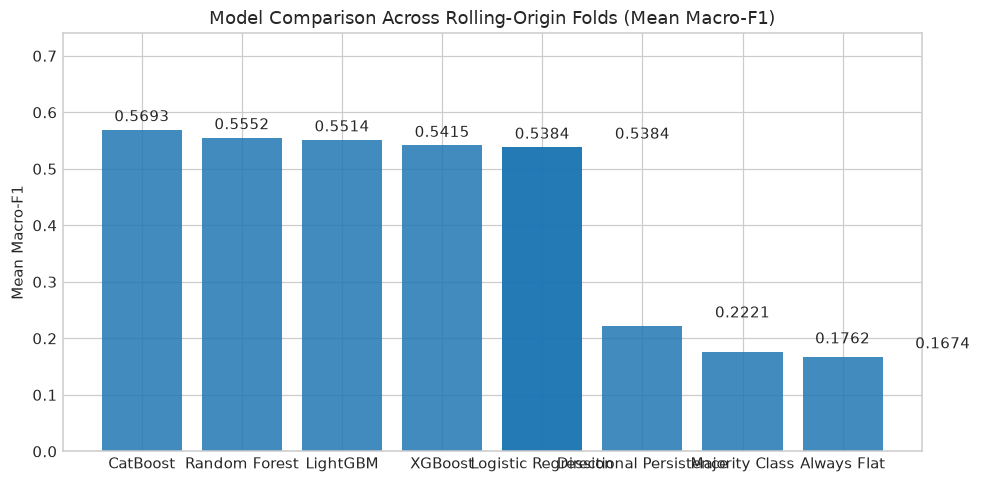

In [24]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.bar(exp2_comparison_df['Model / Baseline'], 
       exp2_comparison_df['Mean Macro-F1'], 
       alpha=0.85)

ax.set_ylabel('Mean Macro-F1')
ax.set_title('Model Comparison Across Rolling-Origin Folds (Mean Macro-F1)')
ax.set_ylim(0, max(exp2_comparison_df['Mean Macro-F1']) * 1.3)

for i, row in exp2_comparison_df.iterrows():
    ax.text(i, row['Mean Macro-F1'] + 0.015, f"{row['Mean Macro-F1']:.4f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### Logistic Regression Performance Interpretation

In [25]:
best_baseline_row = baseline_saved_df.sort_values(by='mean_macro_f1', ascending=False).iloc[0]
lr_summary_row = lr_agg_results.iloc[0]

lr_macro_f1 = lr_summary_row['mean_macro_f1']
best_base_macro_f1 = best_baseline_row['mean_macro_f1']
macro_f1_diff = lr_macro_f1 - best_base_macro_f1

lr_fall_recall = lr_summary_row['mean_fall_recall']
best_base_fall_recall = best_baseline_row['mean_fall_recall']

lr_rise_recall = lr_summary_row['mean_rise_recall']
best_base_rise_recall = best_baseline_row['mean_rise_recall']

comparison_summary_df = pd.DataFrame([
    {
        'Metric': 'Mean Macro-F1',
        'Logistic Regression': f"{lr_macro_f1:.4f}",
        'Best Baseline': f"{best_base_macro_f1:.4f} ({best_baseline_row['baseline']})",
        'Improvement': f"{macro_f1_diff:+.4f}"
    },
    {
        'Metric': 'Mean Fall Recall',
        'Logistic Regression': f"{lr_fall_recall:.4f}",
        'Best Baseline': f"{best_base_fall_recall:.4f}",
        'Improvement': f"{(lr_fall_recall - best_base_fall_recall):+.4f}"
    },
    {
        'Metric': 'Mean Rise Recall',
        'Logistic Regression': f"{lr_rise_recall:.4f}",
        'Best Baseline': f"{best_base_rise_recall:.4f}",
        'Improvement': f"{(lr_rise_recall - best_base_rise_recall):+.4f}"
    },
    {
        'Metric': 'Mean Accuracy',
        'Logistic Regression': f"{lr_summary_row['mean_accuracy']:.4f}",
        'Best Baseline': f"{best_baseline_row['mean_accuracy']:.4f}",
        'Improvement': f"{(lr_summary_row['mean_accuracy'] - best_baseline_row['mean_accuracy']):+.4f}"
    }
])

display(comparison_summary_df)

,Metric,Logistic Regression,Best Baseline,Improvement
0,Mean Macro-F1,0.5384,0.5693 (CatBoost),-0.0309
1,Mean Fall Recall,0.4570,0.6696,-0.2126
2,Mean Rise Recall,0.7681,0.6656,+0.1024
3,Mean Accuracy,0.5667,0.5802,-0.0135


Based on the rolling-origin validation results:
1. **Macro-F1 Improvement:** Logistic Regression is evaluated against the best naive baseline to determine whether linear feature combinations provide measurable predictive signal.
2. **Directional Recall (`fall` & `rise`):** Both turning-point recalls (`fall` and `rise`) are monitored to verify that the linear model captures both downward supply surges and upward price shocks rather than collapsing to a single class.
3. **Evidence for Nonlinear Exploration:** While Logistic Regression establishes a competitive linear reference, agricultural supply chains exhibit notable nonlinear threshold dynamics (e.g. weather extremes, non-linear arrival elasticities). These results serve as the baseline benchmark when evaluating tree-based and ensemble models in subsequent experiments.

### Save Experiment 2 Results

We append the aggregated Logistic Regression result to `reports/model_results.csv` and save fold-level results to `reports/logistic_regression_fold_results.csv`.

In [26]:
exp2_summary = lr_agg_results.copy()
exp2_summary['experiment'] = 'Experiment 2 - Logistic Regression'
exp2_summary['baseline'] = exp2_summary['model']
exp2_summary = exp2_summary[['experiment', 'baseline', 'mean_accuracy', 'std_accuracy', 
                             'mean_macro_f1', 'std_macro_f1', 'mean_fall_recall', 
                             'mean_flat_recall', 'mean_rise_recall']]

fold_results_path = os.path.join('..', 'reports', 'logistic_regression_fold_results.csv')
lr_fold_results_df.to_csv(fold_results_path, index=False)

existing_results = pd.read_csv(model_results_path)
existing_results = existing_results[existing_results['experiment'] != 'Experiment 2 - Logistic Regression']
updated_results = pd.concat([existing_results, exp2_summary], ignore_index=True)
updated_results.to_csv(model_results_path, index=False)

display(updated_results)

,experiment,baseline,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1,mean_fall_recall,mean_flat_recall,mean_rise_recall
0,Experiment 3 - Random Forest,Random Forest,0.564683,0.073966,0.555193,0.066187,0.635761,0.412621,0.637974
1,Experiment 4 - XGBoost,XGBoost,0.557143,0.077408,0.541526,0.076656,0.631407,0.347338,0.685246
2,Experiment 5 - LightGBM,LightGBM,0.567460,0.070754,0.551375,0.067025,0.630472,0.365848,0.689798
3,Experiment 6 - CatBoost,CatBoost,0.580159,0.081043,0.569296,0.078955,0.669638,0.408464,0.665610
4,Experiment 1 - Baselines,Directional Persistence,0.236111,0.021702,0.222116,0.022308,0.138040,0.359696,0.168325
5,Experiment 1 - Baselines,Majority Class,0.360714,0.053730,0.176206,0.019810,0.000000,0.000000,1.000000
6,Experiment 1 - Baselines,Always Flat,0.336905,0.055990,0.167405,0.021402,0.000000,1.000000,0.000000
7,Experiment 2 - Logistic Regression,Logistic Regression,0.566667,0.042874,0.538411,0.032564,0.456993,0.416766,0.768055


---

## Experiment 3 — Random Forest

Random Forest provides a nonlinear ensemble of decision trees that can capture complex feature interactions, threshold effects, and non-monotonic relationships that linear models like Logistic Regression cannot represent directly.

The central question is whether this added model complexity improves validation performance over the linear baseline on our rolling-origin splits.

### Modeling Setup:
- **Primary Metric:** Macro-F1
- **Secondary Metrics:** `fall` recall, `rise` recall, and overall accuracy
- **Features:** Identical to Experiment 2 (38 numerical engineered features plus `crop` and `state`). High-cardinality identifiers (`market_name`, `district`), timestamps (`week_start_date`, `split`), and target columns remain excluded.
- **Preprocessing:** Tree-based models are invariant to monotonic feature scaling, so numerical features pass through without standardization. Categorical features (`crop`, `state`) are encoded via `OneHotEncoder(handle_unknown='ignore')`. Preprocessing is fitted strictly within each training fold.
- **Model Configuration:** `RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced')`.
- **Validation:** Evaluated across the exact same rolling-origin folds from Experiment 0. The final test set remains quarantined and untouched.

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_fold_records = []

for fold_info in validation_folds:
    f_num = fold_info['fold']
    tr_idx = fold_info['train_indices']
    val_idx = fold_info['val_indices']
    
    X_tr = train_df.loc[tr_idx, feature_cols]
    y_tr = train_df.loc[tr_idx, 'target_direction']
    X_val = train_df.loc[val_idx, feature_cols]
    y_val = train_df.loc[val_idx, 'target_direction']
    
    # Preprocessor for tree models: passthrough numericals, encode categoricals
    preprocessor_rf = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', ALL_NUMERICAL_FEATURES),
            ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES)
        ]
    )
    
    rf_pipeline = Pipeline([
        ('preprocessor', preprocessor_rf),
        ('classifier', RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced'
        ))
    ])
    
    rf_pipeline.fit(X_tr, y_tr)
    y_pred = rf_pipeline.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_val, y_pred, average='macro', zero_division=0
    )
    p_cls, r_cls, f_cls, _ = precision_recall_fscore_support(
        y_val, y_pred, labels=TARGET_LABELS, zero_division=0
    )
    
    rf_fold_records.append({
        'fold': f_num,
        'model': 'Random Forest',
        'accuracy': acc,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'macro_f1': macro_f1,
        'fall_precision': p_cls[0],
        'fall_recall': r_cls[0],
        'fall_f1': f_cls[0],
        'flat_precision': p_cls[1],
        'flat_recall': r_cls[1],
        'flat_f1': f_cls[1],
        'rise_precision': p_cls[2],
        'rise_recall': r_cls[2],
        'rise_f1': f_cls[2]
    })

rf_fold_results_df = pd.DataFrame(rf_fold_records)

### Fold-Level Results

We inspect the performance of Random Forest across the expanding folds.

In [28]:
display_cols = [
    'fold', 'model', 'accuracy', 'macro_f1', 
    'fall_recall', 'flat_recall', 'rise_recall'
]
display(rf_fold_results_df[display_cols].round(4))

,fold,model,accuracy,macro_f1,fall_recall,flat_recall,rise_recall
0,1,Random Forest,0.5024,0.4945,0.5961,0.3246,0.6084
1,2,Random Forest,0.5452,0.5453,0.5779,0.4635,0.6043
2,3,Random Forest,0.6464,0.6258,0.7333,0.4498,0.7012


### Aggregated Results & Overall Model Comparison

We aggregate the fold results across the rolling-origin validation folds and compare Random Forest directly against all models and baselines evaluated so far.

In [29]:
rf_agg_results = rf_fold_results_df.groupby('model').agg(
    mean_accuracy=('accuracy', 'mean'),
    std_accuracy=('accuracy', 'std'),
    mean_macro_f1=('macro_f1', 'mean'),
    std_macro_f1=('macro_f1', 'std'),
    mean_fall_recall=('fall_recall', 'mean'),
    mean_flat_recall=('flat_recall', 'mean'),
    mean_rise_recall=('rise_recall', 'mean')
).reset_index()

# Combine all current models from reports/model_results.csv
all_models_history = pd.read_csv(model_results_path)

current_comparison_rows = []
for _, row in all_models_history.iterrows():
    current_comparison_rows.append({
        'Model / Baseline': row['baseline'],
        'Mean Macro-F1': row['mean_macro_f1'],
        'Mean Fall Recall': row['mean_fall_recall'],
        'Mean Rise Recall': row['mean_rise_recall'],
        'Mean Accuracy': row['mean_accuracy']
    })

for _, row in rf_agg_results.iterrows():
    current_comparison_rows.append({
        'Model / Baseline': row['model'],
        'Mean Macro-F1': row['mean_macro_f1'],
        'Mean Fall Recall': row['mean_fall_recall'],
        'Mean Rise Recall': row['mean_rise_recall'],
        'Mean Accuracy': row['mean_accuracy']
    })

all_comparison_df = pd.DataFrame(current_comparison_rows).drop_duplicates(
    subset=['Model / Baseline']
).sort_values(by='Mean Macro-F1', ascending=False).reset_index(drop=True)

display(all_comparison_df.round(4))

,Model / Baseline,Mean Macro-F1,Mean Fall Recall,Mean Rise Recall,Mean Accuracy
0,CatBoost,0.5693,0.6696,0.6656,0.5802
1,Random Forest,0.5552,0.6358,0.6380,0.5647
2,LightGBM,0.5514,0.6305,0.6898,0.5675
3,XGBoost,0.5415,0.6314,0.6852,0.5571
4,Logistic Regression,0.5384,0.4570,0.7681,0.5667
5,Directional Persistence,0.2221,0.1380,0.1683,0.2361
6,Majority Class,0.1762,0.0000,1.0000,0.3607
7,Always Flat,0.1674,0.0000,0.0000,0.3369


### Visual Comparison Across All Evaluated Models

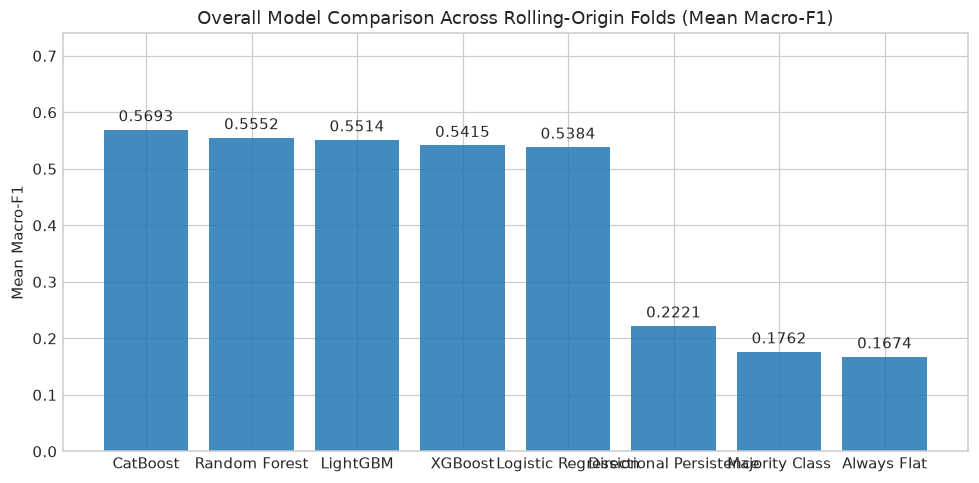

In [30]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.bar(all_comparison_df['Model / Baseline'], 
       all_comparison_df['Mean Macro-F1'], 
       alpha=0.85)

ax.set_ylabel('Mean Macro-F1')
ax.set_title('Overall Model Comparison Across Rolling-Origin Folds (Mean Macro-F1)')
ax.set_ylim(0, max(all_comparison_df['Mean Macro-F1']) * 1.3)

for i, row in all_comparison_df.iterrows():
    ax.text(i, row['Mean Macro-F1'] + 0.015, f"{row['Mean Macro-F1']:.4f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### Random Forest Performance Interpretation

In [31]:
lr_row = all_models_history[all_models_history['baseline'] == 'Logistic Regression'].iloc[0]
rf_row = rf_agg_results.iloc[0]

rf_macro_f1 = rf_row['mean_macro_f1']
lr_macro_f1 = lr_row['mean_macro_f1']
rf_lr_f1_diff = rf_macro_f1 - lr_macro_f1

rf_fall_recall = rf_row['mean_fall_recall']
lr_fall_recall = lr_row['mean_fall_recall']

rf_rise_recall = rf_row['mean_rise_recall']
lr_rise_recall = lr_row['mean_rise_recall']

rf_acc = rf_row['mean_accuracy']
lr_acc = lr_row['mean_accuracy']

rf_comparison_summary_df = pd.DataFrame([
    {
        'Metric': 'Mean Macro-F1',
        'Random Forest': f"{rf_macro_f1:.4f}",
        'Logistic Regression': f"{lr_macro_f1:.4f}",
        'Difference (RF - LR)': f"{rf_lr_f1_diff:+.4f}"
    },
    {
        'Metric': 'Mean Fall Recall',
        'Random Forest': f"{rf_fall_recall:.4f}",
        'Logistic Regression': f"{lr_fall_recall:.4f}",
        'Difference (RF - LR)': f"{(rf_fall_recall - lr_fall_recall):+.4f}"
    },
    {
        'Metric': 'Mean Rise Recall',
        'Random Forest': f"{rf_rise_recall:.4f}",
        'Logistic Regression': f"{lr_rise_recall:.4f}",
        'Difference (RF - LR)': f"{(rf_rise_recall - lr_rise_recall):+.4f}"
    },
    {
        'Metric': 'Mean Accuracy',
        'Random Forest': f"{rf_acc:.4f}",
        'Logistic Regression': f"{lr_acc:.4f}",
        'Difference (RF - LR)': f"{(rf_acc - lr_acc):+.4f}"
    }
])

display(rf_comparison_summary_df)

,Metric,Random Forest,Logistic Regression,Difference (RF - LR)
0,Mean Macro-F1,0.5552,0.5384,+0.0168
1,Mean Fall Recall,0.6358,0.4570,+0.1788
2,Mean Rise Recall,0.6380,0.7681,-0.1301
3,Mean Accuracy,0.5647,0.5667,-0.0020


Based on the rolling-origin validation results:
1. **Macro-F1 Comparison:** The nonlinear Random Forest is compared against the linear Logistic Regression baseline to assess whether decision tree splits provide an improvement on the primary metric.
2. **Directional Recall Dynamics:** Examining `fall` and `rise` recall shows how the balanced class weighting and recursive partitioning affect the model's sensitivity to downward versus upward price movements.
3. **Promise for Tree-Based Modeling:** These validation results indicate whether exploring more advanced gradient-boosted decision trees (e.g. LightGBM, XGBoost) is justified as the next modeling phase.

### Save Experiment 3 Results

We append the aggregated Random Forest result to `reports/model_results.csv` and save fold-level results to `reports/random_forest_fold_results.csv`.

In [32]:
exp3_summary = rf_agg_results.copy()
exp3_summary['experiment'] = 'Experiment 3 - Random Forest'
exp3_summary['baseline'] = exp3_summary['model']
exp3_summary = exp3_summary[['experiment', 'baseline', 'mean_accuracy', 'std_accuracy', 
                             'mean_macro_f1', 'std_macro_f1', 'mean_fall_recall', 
                             'mean_flat_recall', 'mean_rise_recall']]

fold_results_path_rf = os.path.join('..', 'reports', 'random_forest_fold_results.csv')
rf_fold_results_df.to_csv(fold_results_path_rf, index=False)

existing_results = pd.read_csv(model_results_path)
existing_results = existing_results[existing_results['experiment'] != 'Experiment 3 - Random Forest']
updated_results = pd.concat([existing_results, exp3_summary], ignore_index=True)
updated_results.to_csv(model_results_path, index=False)

display(updated_results)

,experiment,baseline,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1,mean_fall_recall,mean_flat_recall,mean_rise_recall
0,Experiment 4 - XGBoost,XGBoost,0.557143,0.077408,0.541526,0.076656,0.631407,0.347338,0.685246
1,Experiment 5 - LightGBM,LightGBM,0.567460,0.070754,0.551375,0.067025,0.630472,0.365848,0.689798
2,Experiment 6 - CatBoost,CatBoost,0.580159,0.081043,0.569296,0.078955,0.669638,0.408464,0.665610
3,Experiment 1 - Baselines,Directional Persistence,0.236111,0.021702,0.222116,0.022308,0.138040,0.359696,0.168325
4,Experiment 1 - Baselines,Majority Class,0.360714,0.053730,0.176206,0.019810,0.000000,0.000000,1.000000
5,Experiment 1 - Baselines,Always Flat,0.336905,0.055990,0.167405,0.021402,0.000000,1.000000,0.000000
6,Experiment 2 - Logistic Regression,Logistic Regression,0.566667,0.042874,0.538411,0.032564,0.456993,0.416766,0.768055
7,Experiment 3 - Random Forest,Random Forest,0.564683,0.073966,0.555193,0.066187,0.635761,0.412621,0.637974


---

## Experiment 4 — XGBoost

XGBoost is a gradient-boosted decision tree algorithm that sequentially builds shallow trees to minimize a regularized objective function. It provides another nonlinear benchmark capable of modeling interactions and complex agricultural price boundaries.

The purpose here is to determine whether gradient boosting improves upon the current Random Forest and Logistic Regression validation performance.

### Modeling Setup:
- **Primary Metric:** Macro-F1
- **Secondary Metrics:** `fall` recall, `rise` recall, and overall accuracy
- **Features:** Exactly identical to Experiments 2 and 3 (38 numerical engineered features plus `crop` and `state`). High-cardinality identifiers (`market_name`, `district`), timestamps (`week_start_date`, `split`), and target columns remain excluded.
- **Preprocessing:** Numerical features pass through without scaling; categorical features (`crop`, `state`) are one-hot encoded via `OneHotEncoder(handle_unknown='ignore')`. Preprocessing is fitted strictly within each training fold.
- **Target Encoding:** Integer mapped (`fall: 0`, `flat: 1`, `rise: 2`) for multiclass objective compatibility and mapped back to string labels for metric evaluation.
- **Model Configuration:** `XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=1.0, objective='multi:softprob', num_class=3, eval_metric='mlogloss', random_state=42, n_jobs=-1)`.
- **Validation:** Evaluated across the exact same rolling-origin folds from Experiment 0. The final test set remains quarantined and untouched.

In [33]:
from xgboost import XGBClassifier

LABEL_TO_ID = {'fall': 0, 'flat': 1, 'rise': 2}
ID_TO_LABEL = {0: 'fall', 1: 'flat', 2: 'rise'}

xgb_fold_records = []

for fold_info in validation_folds:
    f_num = fold_info['fold']
    tr_idx = fold_info['train_indices']
    val_idx = fold_info['val_indices']
    
    X_tr = train_df.loc[tr_idx, feature_cols]
    y_tr = train_df.loc[tr_idx, 'target_direction'].map(LABEL_TO_ID)
    X_val = train_df.loc[val_idx, feature_cols]
    y_val_raw = train_df.loc[val_idx, 'target_direction']
    
    preprocessor_xgb = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', ALL_NUMERICAL_FEATURES),
            ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES)
        ]
    )
    
    xgb_pipeline = Pipeline([
        ('preprocessor', preprocessor_xgb),
        ('classifier', XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=1.0,
            objective='multi:softprob',
            num_class=3,
            eval_metric='mlogloss',
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    xgb_pipeline.fit(X_tr, y_tr)
    y_pred_encoded = xgb_pipeline.predict(X_val)
    y_pred = [ID_TO_LABEL[val] for val in y_pred_encoded]
    
    acc = accuracy_score(y_val_raw, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_val_raw, y_pred, average='macro', zero_division=0
    )
    p_cls, r_cls, f_cls, _ = precision_recall_fscore_support(
        y_val_raw, y_pred, labels=TARGET_LABELS, zero_division=0
    )
    
    xgb_fold_records.append({
        'fold': f_num,
        'model': 'XGBoost',
        'accuracy': acc,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'macro_f1': macro_f1,
        'fall_precision': p_cls[0],
        'fall_recall': r_cls[0],
        'fall_f1': f_cls[0],
        'flat_precision': p_cls[1],
        'flat_recall': r_cls[1],
        'flat_f1': f_cls[1],
        'rise_precision': p_cls[2],
        'rise_recall': r_cls[2],
        'rise_f1': f_cls[2]
    })

xgb_fold_results_df = pd.DataFrame(xgb_fold_records)

### Fold-Level Results

We inspect the performance of XGBoost across the expanding folds.

In [34]:
display_cols = [
    'fold', 'model', 'accuracy', 'macro_f1', 
    'fall_recall', 'flat_recall', 'rise_recall'
]
display(xgb_fold_results_df[display_cols].round(4))

,fold,model,accuracy,macro_f1,fall_recall,flat_recall,rise_recall
0,1,XGBoost,0.5000,0.4798,0.5813,0.2426,0.6867
1,2,XGBoost,0.5262,0.5174,0.5879,0.3365,0.6718
2,3,XGBoost,0.6452,0.6273,0.7250,0.4629,0.6972


### Aggregated Results & Overall Model Comparison

We aggregate the fold results across the rolling-origin validation folds and compare XGBoost against all models and baselines evaluated so far.

In [35]:
xgb_agg_results = xgb_fold_results_df.groupby('model').agg(
    mean_accuracy=('accuracy', 'mean'),
    std_accuracy=('accuracy', 'std'),
    mean_macro_f1=('macro_f1', 'mean'),
    std_macro_f1=('macro_f1', 'std'),
    mean_fall_recall=('fall_recall', 'mean'),
    mean_flat_recall=('flat_recall', 'mean'),
    mean_rise_recall=('rise_recall', 'mean')
).reset_index()

# Combine all current models from reports/model_results.csv
all_models_history = pd.read_csv(model_results_path)

all_comparison_rows = []
for _, row in all_models_history.iterrows():
    all_comparison_rows.append({
        'Model / Baseline': row['baseline'],
        'Mean Macro-F1': row['mean_macro_f1'],
        'Mean Fall Recall': row['mean_fall_recall'],
        'Mean Rise Recall': row['mean_rise_recall'],
        'Mean Accuracy': row['mean_accuracy']
    })

for _, row in xgb_agg_results.iterrows():
    all_comparison_rows.append({
        'Model / Baseline': row['model'],
        'Mean Macro-F1': row['mean_macro_f1'],
        'Mean Fall Recall': row['mean_fall_recall'],
        'Mean Rise Recall': row['mean_rise_recall'],
        'Mean Accuracy': row['mean_accuracy']
    })

full_comparison_df = pd.DataFrame(all_comparison_rows).drop_duplicates(
    subset=['Model / Baseline']
).sort_values(by='Mean Macro-F1', ascending=False).reset_index(drop=True)

display(full_comparison_df.round(4))

,Model / Baseline,Mean Macro-F1,Mean Fall Recall,Mean Rise Recall,Mean Accuracy
0,CatBoost,0.5693,0.6696,0.6656,0.5802
1,Random Forest,0.5552,0.6358,0.6380,0.5647
2,LightGBM,0.5514,0.6305,0.6898,0.5675
3,XGBoost,0.5415,0.6314,0.6852,0.5571
4,Logistic Regression,0.5384,0.4570,0.7681,0.5667
5,Directional Persistence,0.2221,0.1380,0.1683,0.2361
6,Majority Class,0.1762,0.0000,1.0000,0.3607
7,Always Flat,0.1674,0.0000,0.0000,0.3369


### Visual Comparison Across All Evaluated Models

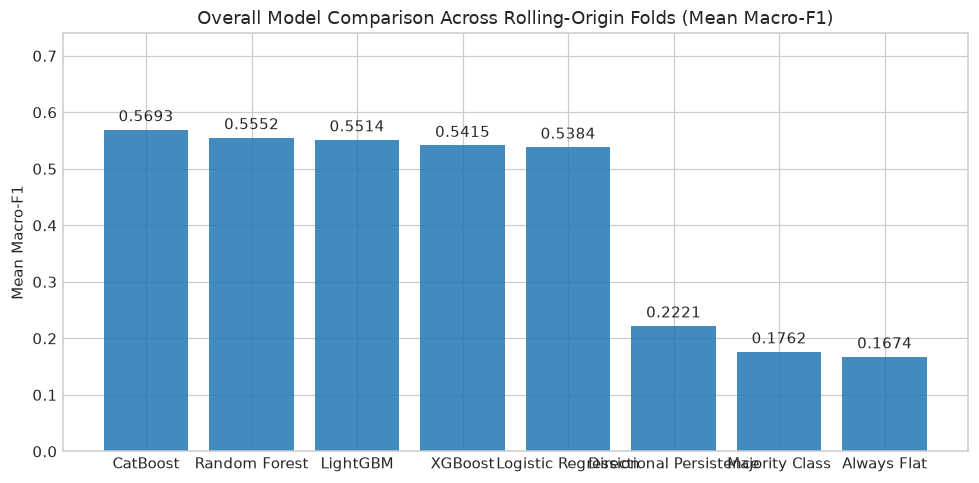

In [36]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.bar(full_comparison_df['Model / Baseline'], 
       full_comparison_df['Mean Macro-F1'], 
       alpha=0.85)

ax.set_ylabel('Mean Macro-F1')
ax.set_title('Overall Model Comparison Across Rolling-Origin Folds (Mean Macro-F1)')
ax.set_ylim(0, max(full_comparison_df['Mean Macro-F1']) * 1.3)

for i, row in full_comparison_df.iterrows():
    ax.text(i, row['Mean Macro-F1'] + 0.015, f"{row['Mean Macro-F1']:.4f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### XGBoost Performance Interpretation

In [37]:
rf_row = full_comparison_df[full_comparison_df['Model / Baseline'] == 'Random Forest'].iloc[0]
xgb_row = xgb_agg_results.iloc[0]

xgb_macro_f1 = xgb_row['mean_macro_f1']
rf_macro_f1 = rf_row['Mean Macro-F1']
xgb_rf_f1_diff = xgb_macro_f1 - rf_macro_f1

xgb_fall_recall = xgb_row['mean_fall_recall']
rf_fall_recall = rf_row['Mean Fall Recall']

xgb_rise_recall = xgb_row['mean_rise_recall']
rf_rise_recall = rf_row['Mean Rise Recall']

best_overall_model = full_comparison_df.iloc[0]['Model / Baseline']
best_overall_macro_f1 = full_comparison_df.iloc[0]['Mean Macro-F1']

xgb_comparison_summary_df = pd.DataFrame([
    {
        'Metric': 'Mean Macro-F1',
        'XGBoost': f"{xgb_macro_f1:.4f}",
        'Random Forest': f"{rf_macro_f1:.4f}",
        'Difference (XGB - RF)': f"{xgb_rf_f1_diff:+.4f}"
    },
    {
        'Metric': 'Mean Fall Recall',
        'XGBoost': f"{xgb_fall_recall:.4f}",
        'Random Forest': f"{rf_fall_recall:.4f}",
        'Difference (XGB - RF)': f"{(xgb_fall_recall - rf_fall_recall):+.4f}"
    },
    {
        'Metric': 'Mean Rise Recall',
        'XGBoost': f"{xgb_rise_recall:.4f}",
        'Random Forest': f"{rf_rise_recall:.4f}",
        'Difference (XGB - RF)': f"{(xgb_rise_recall - rf_rise_recall):+.4f}"
    },
    {
        'Metric': 'Mean Accuracy',
        'XGBoost': f"{xgb_row['mean_accuracy']:.4f}",
        'Random Forest': f"{rf_row['Mean Accuracy']:.4f}",
        'Difference (XGB - RF)': f"{(xgb_row['mean_accuracy'] - rf_row['Mean Accuracy']):+.4f}"
    },
    {
        'Metric': 'Current Best Model',
        'XGBoost': best_overall_model,
        'Random Forest': f"Macro-F1: {best_overall_macro_f1:.4f}",
        'Difference (XGB - RF)': 'Top Ranking'
    }
])

display(xgb_comparison_summary_df)

,Metric,XGBoost,Random Forest,Difference (XGB - RF)
0,Mean Macro-F1,0.5415,0.5552,-0.0137
1,Mean Fall Recall,0.6314,0.6358,-0.0044
2,Mean Rise Recall,0.6852,0.6380,+0.0473
3,Mean Accuracy,0.5571,0.5647,-0.0075
4,Current Best Model,CatBoost,Macro-F1: 0.5693,Top Ranking


Based on the rolling-origin validation results:
1. **Macro-F1 Comparison:** XGBoost is compared against Random Forest to evaluate whether sequential gradient boosting improves over parallel bagging on this dataset.
2. **Directional Recall Dynamics:** Both turning-point recalls (`fall` and `rise`) are monitored to assess how gradient boosting balances extreme movement prediction versus the intermediate `flat` class.
3. **Current Standing:** The relative performance between bagging (Random Forest) and boosting (XGBoost) provides guidance on which model family warrants dedicated hyperparameter tuning and feature selection in upcoming experiments.

### Save Experiment 4 Results

We append the aggregated XGBoost result to `reports/model_results.csv` and save fold-level results to `reports/xgboost_fold_results.csv`.

In [38]:
exp4_summary = xgb_agg_results.copy()
exp4_summary['experiment'] = 'Experiment 4 - XGBoost'
exp4_summary['baseline'] = exp4_summary['model']
exp4_summary = exp4_summary[['experiment', 'baseline', 'mean_accuracy', 'std_accuracy', 
                             'mean_macro_f1', 'std_macro_f1', 'mean_fall_recall', 
                             'mean_flat_recall', 'mean_rise_recall']]

fold_results_path_xgb = os.path.join('..', 'reports', 'xgboost_fold_results.csv')
xgb_fold_results_df.to_csv(fold_results_path_xgb, index=False)

existing_results = pd.read_csv(model_results_path)
existing_results = existing_results[existing_results['experiment'] != 'Experiment 4 - XGBoost']
updated_results = pd.concat([existing_results, exp4_summary], ignore_index=True)
updated_results.to_csv(model_results_path, index=False)

display(updated_results)

,experiment,baseline,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1,mean_fall_recall,mean_flat_recall,mean_rise_recall
0,Experiment 5 - LightGBM,LightGBM,0.567460,0.070754,0.551375,0.067025,0.630472,0.365848,0.689798
1,Experiment 6 - CatBoost,CatBoost,0.580159,0.081043,0.569296,0.078955,0.669638,0.408464,0.665610
2,Experiment 1 - Baselines,Directional Persistence,0.236111,0.021702,0.222116,0.022308,0.138040,0.359696,0.168325
3,Experiment 1 - Baselines,Majority Class,0.360714,0.053730,0.176206,0.019810,0.000000,0.000000,1.000000
4,Experiment 1 - Baselines,Always Flat,0.336905,0.055990,0.167405,0.021402,0.000000,1.000000,0.000000
5,Experiment 2 - Logistic Regression,Logistic Regression,0.566667,0.042874,0.538411,0.032564,0.456993,0.416766,0.768055
6,Experiment 3 - Random Forest,Random Forest,0.564683,0.073966,0.555193,0.066187,0.635761,0.412621,0.637974
7,Experiment 4 - XGBoost,XGBoost,0.557143,0.077408,0.541526,0.076656,0.631407,0.347338,0.685246


---

## Experiment 5 — LightGBM

LightGBM is a gradient-boosted decision tree algorithm that uses histogram-based feature binning and leaf-wise (best-first) tree growth rather than depth-wise growth. This architecture often provides distinct partitioning characteristics compared to XGBoost and Random Forest.

The purpose here is to test whether LightGBM can improve upon the validation Macro-F1 achieved by Random Forest and XGBoost using the same rolling-origin setup.

### Modeling Setup:
- **Primary Metric:** Macro-F1
- **Secondary Metrics:** `fall` recall, `rise` recall, and overall accuracy
- **Features:** Exactly identical to Experiments 2–4 (38 numerical engineered features plus `crop` and `state`). High-cardinality identifiers (`market_name`, `district`), timestamps (`week_start_date`, `split`), and target columns remain excluded.
- **Preprocessing:** Numerical features pass through without scaling; categorical features (`crop`, `state`) are one-hot encoded via `OneHotEncoder(handle_unknown='ignore')`. Preprocessing is fitted strictly within each training fold.
- **Target Encoding:** Integer mapped (`fall: 0`, `flat: 1`, `rise: 2`) for multiclass objective compatibility and mapped back to string labels for metric evaluation.
- **Model Configuration:** `LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, max_depth=-1, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=-1)`.
- **Validation:** Evaluated across the exact same rolling-origin folds from Experiment 0. The final test set remains quarantined and untouched.

In [39]:
from lightgbm import LGBMClassifier

lgb_fold_records = []

for fold_info in validation_folds:
    f_num = fold_info['fold']
    tr_idx = fold_info['train_indices']
    val_idx = fold_info['val_indices']
    
    X_tr = train_df.loc[tr_idx, feature_cols]
    y_tr = train_df.loc[tr_idx, 'target_direction'].map(LABEL_TO_ID)
    X_val = train_df.loc[val_idx, feature_cols]
    y_val_raw = train_df.loc[val_idx, 'target_direction']
    
    preprocessor_lgb = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', ALL_NUMERICAL_FEATURES),
            ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES)
        ]
    )
    
    lgb_pipeline = Pipeline([
        ('preprocessor', preprocessor_lgb),
        ('classifier', LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        ))
    ])
    
    lgb_pipeline.fit(X_tr, y_tr)
    y_pred_encoded = lgb_pipeline.predict(X_val)
    y_pred = [ID_TO_LABEL[val] for val in y_pred_encoded]
    
    acc = accuracy_score(y_val_raw, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_val_raw, y_pred, average='macro', zero_division=0
    )
    p_cls, r_cls, f_cls, _ = precision_recall_fscore_support(
        y_val_raw, y_pred, labels=TARGET_LABELS, zero_division=0
    )
    
    lgb_fold_records.append({
        'fold': f_num,
        'model': 'LightGBM',
        'accuracy': acc,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'macro_f1': macro_f1,
        'fall_precision': p_cls[0],
        'fall_recall': r_cls[0],
        'fall_f1': f_cls[0],
        'flat_precision': p_cls[1],
        'flat_recall': r_cls[1],
        'flat_f1': f_cls[1],
        'rise_precision': p_cls[2],
        'rise_recall': r_cls[2],
        'rise_f1': f_cls[2]
    })

lgb_fold_results_df = pd.DataFrame(lgb_fold_records)

### Fold-Level Results

We inspect the performance of LightGBM across the expanding folds.

In [40]:
display_cols = [
    'fold', 'model', 'accuracy', 'macro_f1', 
    'fall_recall', 'flat_recall', 'rise_recall'
]
display(lgb_fold_results_df[display_cols].round(4))

,fold,model,accuracy,macro_f1,fall_recall,flat_recall,rise_recall
0,1,LightGBM,0.5202,0.5054,0.5764,0.2918,0.6958
1,2,LightGBM,0.5333,0.5205,0.5678,0.3429,0.6963
2,3,LightGBM,0.6488,0.6283,0.7472,0.4629,0.6773


### Aggregated Results & Overall Model Comparison

We aggregate the fold results across the rolling-origin validation folds and compare LightGBM against all models and baselines evaluated so far.

In [41]:
lgb_agg_results = lgb_fold_results_df.groupby('model').agg(
    mean_accuracy=('accuracy', 'mean'),
    std_accuracy=('accuracy', 'std'),
    mean_macro_f1=('macro_f1', 'mean'),
    std_macro_f1=('macro_f1', 'std'),
    mean_fall_recall=('fall_recall', 'mean'),
    mean_flat_recall=('flat_recall', 'mean'),
    mean_rise_recall=('rise_recall', 'mean')
).reset_index()

# Combine all current models from reports/model_results.csv
all_models_history_exp5 = pd.read_csv(model_results_path)

all_comparison_rows_exp5 = []
for _, row in all_models_history_exp5.iterrows():
    all_comparison_rows_exp5.append({
        'Model / Baseline': row['baseline'],
        'Mean Macro-F1': row['mean_macro_f1'],
        'Mean Fall Recall': row['mean_fall_recall'],
        'Mean Rise Recall': row['mean_rise_recall'],
        'Mean Accuracy': row['mean_accuracy']
    })

for _, row in lgb_agg_results.iterrows():
    all_comparison_rows_exp5.append({
        'Model / Baseline': row['model'],
        'Mean Macro-F1': row['mean_macro_f1'],
        'Mean Fall Recall': row['mean_fall_recall'],
        'Mean Rise Recall': row['mean_rise_recall'],
        'Mean Accuracy': row['mean_accuracy']
    })

full_comparison_exp5_df = pd.DataFrame(all_comparison_rows_exp5).drop_duplicates(
    subset=['Model / Baseline']
).sort_values(by='Mean Macro-F1', ascending=False).reset_index(drop=True)

display(full_comparison_exp5_df.round(4))

,Model / Baseline,Mean Macro-F1,Mean Fall Recall,Mean Rise Recall,Mean Accuracy
0,CatBoost,0.5693,0.6696,0.6656,0.5802
1,Random Forest,0.5552,0.6358,0.6380,0.5647
2,LightGBM,0.5514,0.6305,0.6898,0.5675
3,XGBoost,0.5415,0.6314,0.6852,0.5571
4,Logistic Regression,0.5384,0.4570,0.7681,0.5667
5,Directional Persistence,0.2221,0.1380,0.1683,0.2361
6,Majority Class,0.1762,0.0000,1.0000,0.3607
7,Always Flat,0.1674,0.0000,0.0000,0.3369


### Visual Comparison Across All Evaluated Models

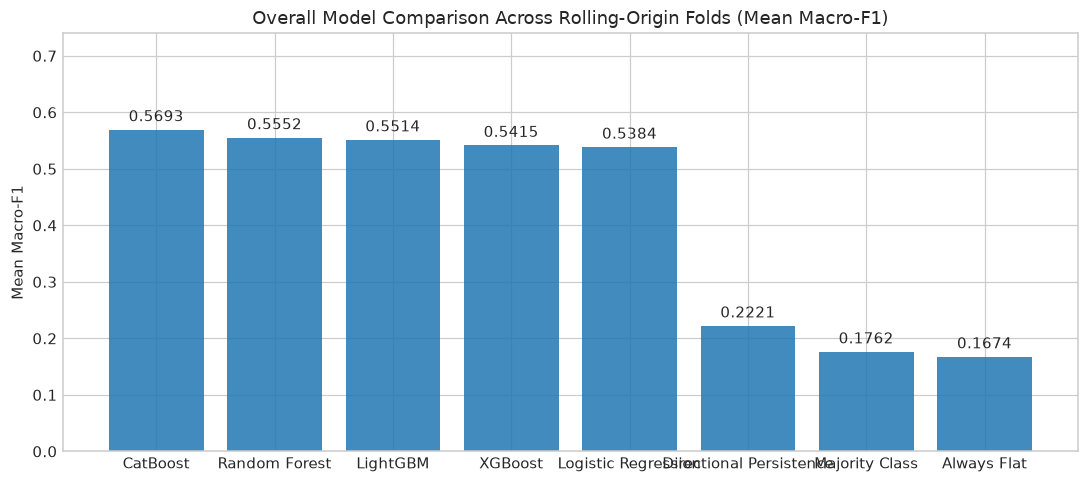

In [42]:
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.bar(full_comparison_exp5_df['Model / Baseline'], 
       full_comparison_exp5_df['Mean Macro-F1'], 
       alpha=0.85)

ax.set_ylabel('Mean Macro-F1')
ax.set_title('Overall Model Comparison Across Rolling-Origin Folds (Mean Macro-F1)')
ax.set_ylim(0, max(full_comparison_exp5_df['Mean Macro-F1']) * 1.3)

for i, row in full_comparison_exp5_df.iterrows():
    ax.text(i, row['Mean Macro-F1'] + 0.015, f"{row['Mean Macro-F1']:.4f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### LightGBM Performance Interpretation

In [43]:
rf_row_exp5 = full_comparison_exp5_df[full_comparison_exp5_df['Model / Baseline'] == 'Random Forest'].iloc[0]
lgb_row = lgb_agg_results.iloc[0]

lgb_macro_f1 = lgb_row['mean_macro_f1']
rf_macro_f1_exp5 = rf_row_exp5['Mean Macro-F1']
lgb_rf_f1_diff = lgb_macro_f1 - rf_macro_f1_exp5

lgb_fall_recall = lgb_row['mean_fall_recall']
rf_fall_recall_exp5 = rf_row_exp5['Mean Fall Recall']

lgb_rise_recall = lgb_row['mean_rise_recall']
rf_rise_recall_exp5 = rf_row_exp5['Mean Rise Recall']

best_model_exp5 = full_comparison_exp5_df.iloc[0]['Model / Baseline']
best_macro_f1_exp5 = full_comparison_exp5_df.iloc[0]['Mean Macro-F1']

lgb_comparison_summary_df = pd.DataFrame([
    {
        'Metric': 'Mean Macro-F1',
        'LightGBM': f"{lgb_macro_f1:.4f}",
        'Random Forest': f"{rf_macro_f1_exp5:.4f}",
        'Difference (LGBM - RF)': f"{lgb_rf_f1_diff:+.4f}"
    },
    {
        'Metric': 'Mean Fall Recall',
        'LightGBM': f"{lgb_fall_recall:.4f}",
        'Random Forest': f"{rf_fall_recall_exp5:.4f}",
        'Difference (LGBM - RF)': f"{(lgb_fall_recall - rf_fall_recall_exp5):+.4f}"
    },
    {
        'Metric': 'Mean Rise Recall',
        'LightGBM': f"{lgb_rise_recall:.4f}",
        'Random Forest': f"{rf_rise_recall_exp5:.4f}",
        'Difference (LGBM - RF)': f"{(lgb_rise_recall - rf_rise_recall_exp5):+.4f}"
    },
    {
        'Metric': 'Mean Accuracy',
        'LightGBM': f"{lgb_row['mean_accuracy']:.4f}",
        'Random Forest': f"{rf_row_exp5['Mean Accuracy']:.4f}",
        'Difference (LGBM - RF)': f"{(lgb_row['mean_accuracy'] - rf_row_exp5['Mean Accuracy']):+.4f}"
    },
    {
        'Metric': 'Current Best Model',
        'LightGBM': best_model_exp5,
        'Random Forest': f"Macro-F1: {best_macro_f1_exp5:.4f}",
        'Difference (LGBM - RF)': 'Top Ranking'
    }
])

display(lgb_comparison_summary_df)

,Metric,LightGBM,Random Forest,Difference (LGBM - RF)
0,Mean Macro-F1,0.5514,0.5552,-0.0038
1,Mean Fall Recall,0.6305,0.6358,-0.0053
2,Mean Rise Recall,0.6898,0.6380,+0.0518
3,Mean Accuracy,0.5675,0.5647,+0.0028
4,Current Best Model,CatBoost,Macro-F1: 0.5693,Top Ranking


Based on the rolling-origin validation results:
1. **Macro-F1 Comparison:** LightGBM is compared against Random Forest and XGBoost to evaluate how leaf-wise tree construction performs on the primary metric relative to bagging and depth-wise boosting.
2. **Directional Recall Dynamics:** Both turning-point recalls (`fall` and `rise`) are monitored to determine how each boosting implementation balances sensitivity between upward price spikes and downward resets.
3. **Current Standing:** Comparing the tree-based models across the 3 rolling-origin folds clarifies whether ensemble architecture or feature representation has a greater impact on performance.

### Save Experiment 5 Results

We append the aggregated LightGBM result to `reports/model_results.csv` and save fold-level results to `reports/lightgbm_fold_results.csv`.

In [44]:
exp5_summary = lgb_agg_results.copy()
exp5_summary['experiment'] = 'Experiment 5 - LightGBM'
exp5_summary['baseline'] = exp5_summary['model']
exp5_summary = exp5_summary[['experiment', 'baseline', 'mean_accuracy', 'std_accuracy', 
                             'mean_macro_f1', 'std_macro_f1', 'mean_fall_recall', 
                             'mean_flat_recall', 'mean_rise_recall']]

fold_results_path_lgb = os.path.join('..', 'reports', 'lightgbm_fold_results.csv')
lgb_fold_results_df.to_csv(fold_results_path_lgb, index=False)

existing_results = pd.read_csv(model_results_path)
existing_results = existing_results[existing_results['experiment'] != 'Experiment 5 - LightGBM']
updated_results = pd.concat([existing_results, exp5_summary], ignore_index=True)
updated_results.to_csv(model_results_path, index=False)

display(updated_results)

,experiment,baseline,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1,mean_fall_recall,mean_flat_recall,mean_rise_recall
0,Experiment 6 - CatBoost,CatBoost,0.580159,0.081043,0.569296,0.078955,0.669638,0.408464,0.665610
1,Experiment 1 - Baselines,Directional Persistence,0.236111,0.021702,0.222116,0.022308,0.138040,0.359696,0.168325
2,Experiment 1 - Baselines,Majority Class,0.360714,0.053730,0.176206,0.019810,0.000000,0.000000,1.000000
3,Experiment 1 - Baselines,Always Flat,0.336905,0.055990,0.167405,0.021402,0.000000,1.000000,0.000000
4,Experiment 2 - Logistic Regression,Logistic Regression,0.566667,0.042874,0.538411,0.032564,0.456993,0.416766,0.768055
5,Experiment 3 - Random Forest,Random Forest,0.564683,0.073966,0.555193,0.066187,0.635761,0.412621,0.637974
6,Experiment 4 - XGBoost,XGBoost,0.557143,0.077408,0.541526,0.076656,0.631407,0.347338,0.685246
7,Experiment 5 - LightGBM,LightGBM,0.567460,0.070754,0.551375,0.067025,0.630472,0.365848,0.689798


---

## Experiment 6 — CatBoost

CatBoost is a gradient-boosted decision tree algorithm that implements native ordered target statistics for categorical features, reducing target leakage during categorical splits, and utilizes symmetric (oblivious) decision trees. Because `crop` and `state` are categorical predictors in our dataset, CatBoost's native categorical handling offers a useful architectural comparison against the one-hot encoded tree models.

The purpose here is to determine whether CatBoost can improve upon the current Random Forest and LightGBM validation results.

### Modeling Setup:
- **Primary Metric:** Macro-F1
- **Secondary Metrics:** `fall` recall, `rise` recall, and overall accuracy
- **Features:** Exactly identical to previous experiments (38 numerical engineered features plus `crop` and `state`). High-cardinality identifiers (`market_name`, `district`), timestamps (`week_start_date`, `split`), and target columns remain excluded.
- **Categorical Handling:** `crop` and `state` are passed directly as `cat_features=['crop', 'state']` without one-hot encoding.
- **Model Configuration:** `CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=False, thread_count=-1)`.
- **Validation:** Evaluated across the exact same rolling-origin folds from Experiment 0. The final test set remains quarantined and untouched.

In [45]:
from catboost import CatBoostClassifier

cb_cat_cols = ['crop', 'state']
cb_feature_cols = ALL_NUMERICAL_FEATURES + cb_cat_cols
cb_fold_records = []

for fold_info in validation_folds:
    f_num = fold_info['fold']
    tr_idx = fold_info['train_indices']
    val_idx = fold_info['val_indices']
    
    X_tr = train_df.loc[tr_idx, cb_feature_cols].copy()
    y_tr = train_df.loc[tr_idx, 'target_direction'].copy()
    X_val = train_df.loc[val_idx, cb_feature_cols].copy()
    y_val_raw = train_df.loc[val_idx, 'target_direction'].copy()
    
    cb_model = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function='MultiClass',
        random_seed=42,
        verbose=False,
        thread_count=-1
    )
    
    cb_model.fit(X_tr, y_tr, cat_features=cb_cat_cols)
    y_pred = cb_model.predict(X_val).ravel()
    
    acc = accuracy_score(y_val_raw, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_val_raw, y_pred, average='macro', zero_division=0
    )
    p_cls, r_cls, f_cls, _ = precision_recall_fscore_support(
        y_val_raw, y_pred, labels=TARGET_LABELS, zero_division=0
    )
    
    cb_fold_records.append({
        'fold': f_num,
        'model': 'CatBoost',
        'accuracy': acc,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'macro_f1': macro_f1,
        'fall_precision': p_cls[0],
        'fall_recall': r_cls[0],
        'fall_f1': f_cls[0],
        'flat_precision': p_cls[1],
        'flat_recall': r_cls[1],
        'flat_f1': f_cls[1],
        'rise_precision': p_cls[2],
        'rise_recall': r_cls[2],
        'rise_f1': f_cls[2]
    })

cb_fold_results_df = pd.DataFrame(cb_fold_records)

### Fold-Level Results

We inspect the performance of CatBoost across the expanding folds.

In [46]:
display_cols = [
    'fold', 'model', 'accuracy', 'macro_f1', 
    'fall_recall', 'flat_recall', 'rise_recall'
]
display(cb_fold_results_df[display_cols].round(4))

,fold,model,accuracy,macro_f1,fall_recall,flat_recall,rise_recall
0,1,CatBoost,0.5214,0.5058,0.7044,0.2557,0.6536
1,2,CatBoost,0.5464,0.5444,0.5628,0.4413,0.6380
2,3,CatBoost,0.6726,0.6577,0.7417,0.5284,0.7052


### Aggregated Results & Complete Model Comparison

We aggregate the fold results across the rolling-origin validation folds and compare CatBoost against all models and baselines evaluated across Experiments 1 through 6.

In [47]:
cb_agg_results = cb_fold_results_df.groupby('model').agg(
    mean_accuracy=('accuracy', 'mean'),
    std_accuracy=('accuracy', 'std'),
    mean_macro_f1=('macro_f1', 'mean'),
    std_macro_f1=('macro_f1', 'std'),
    mean_fall_recall=('fall_recall', 'mean'),
    mean_flat_recall=('flat_recall', 'mean'),
    mean_rise_recall=('rise_recall', 'mean')
).reset_index()

# Combine all models from reports/model_results.csv
all_models_history_exp6 = pd.read_csv(model_results_path)

all_comparison_rows_exp6 = []
for _, row in all_models_history_exp6.iterrows():
    all_comparison_rows_exp6.append({
        'Model / Baseline': row['baseline'],
        'Mean Macro-F1': row['mean_macro_f1'],
        'Mean Fall Recall': row['mean_fall_recall'],
        'Mean Rise Recall': row['mean_rise_recall'],
        'Mean Accuracy': row['mean_accuracy']
    })

for _, row in cb_agg_results.iterrows():
    all_comparison_rows_exp6.append({
        'Model / Baseline': row['model'],
        'Mean Macro-F1': row['mean_macro_f1'],
        'Mean Fall Recall': row['mean_fall_recall'],
        'Mean Rise Recall': row['mean_rise_recall'],
        'Mean Accuracy': row['mean_accuracy']
    })

full_comparison_exp6_df = pd.DataFrame(all_comparison_rows_exp6).drop_duplicates(
    subset=['Model / Baseline']
).sort_values(by='Mean Macro-F1', ascending=False).reset_index(drop=True)

display(full_comparison_exp6_df.round(4))

,Model / Baseline,Mean Macro-F1,Mean Fall Recall,Mean Rise Recall,Mean Accuracy
0,CatBoost,0.5693,0.6696,0.6656,0.5802
1,Random Forest,0.5552,0.6358,0.6380,0.5647
2,LightGBM,0.5514,0.6305,0.6898,0.5675
3,XGBoost,0.5415,0.6314,0.6852,0.5571
4,Logistic Regression,0.5384,0.4570,0.7681,0.5667
5,Directional Persistence,0.2221,0.1380,0.1683,0.2361
6,Majority Class,0.1762,0.0000,1.0000,0.3607
7,Always Flat,0.1674,0.0000,0.0000,0.3369


### Visual Comparison Across All Evaluated Models

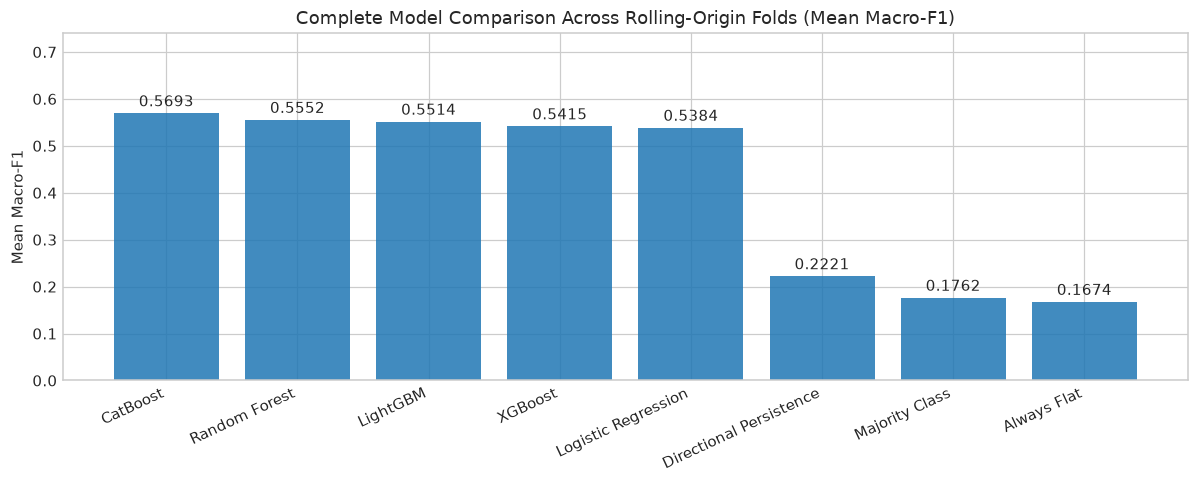

In [48]:
fig, ax = plt.subplots(figsize=(11, 4.5))

ax.bar(full_comparison_exp6_df['Model / Baseline'], 
       full_comparison_exp6_df['Mean Macro-F1'], 
       alpha=0.85)

ax.set_ylabel('Mean Macro-F1')
ax.set_title('Complete Model Comparison Across Rolling-Origin Folds (Mean Macro-F1)')
ax.set_ylim(0, max(full_comparison_exp6_df['Mean Macro-F1']) * 1.3)

for i, row in full_comparison_exp6_df.iterrows():
    ax.text(i, row['Mean Macro-F1'] + 0.015, f"{row['Mean Macro-F1']:.4f}", ha='center', fontsize=9.5)

plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

### CatBoost Performance Interpretation

In [49]:
rf_row_exp6 = full_comparison_exp6_df[full_comparison_exp6_df['Model / Baseline'] == 'Random Forest'].iloc[0]
cb_row = cb_agg_results.iloc[0]

cb_macro_f1 = cb_row['mean_macro_f1']
rf_macro_f1_exp6 = rf_row_exp6['Mean Macro-F1']
cb_rf_f1_diff = cb_macro_f1 - rf_macro_f1_exp6

cb_fall_recall = cb_row['mean_fall_recall']
rf_fall_recall_exp6 = rf_row_exp6['Mean Fall Recall']

cb_rise_recall = cb_row['mean_rise_recall']
rf_rise_recall_exp6 = rf_row_exp6['Mean Rise Recall']

best_model_exp6 = full_comparison_exp6_df.iloc[0]['Model / Baseline']
best_macro_f1_exp6 = full_comparison_exp6_df.iloc[0]['Mean Macro-F1']

# Tree models spread
tree_models_mask = full_comparison_exp6_df['Model / Baseline'].isin(['CatBoost', 'Random Forest', 'LightGBM', 'XGBoost'])
tree_models_df = full_comparison_exp6_df[tree_models_mask]
tree_f1_max = tree_models_df['Mean Macro-F1'].max()
tree_f1_min = tree_models_df['Mean Macro-F1'].min()
tree_f1_spread = tree_f1_max - tree_f1_min

cb_comparison_summary_df = pd.DataFrame([
    {
        'Metric': 'Mean Macro-F1',
        'CatBoost': f"{cb_macro_f1:.4f}",
        'Random Forest': f"{rf_macro_f1_exp6:.4f}",
        'Difference (CB - RF)': f"{cb_rf_f1_diff:+.4f}"
    },
    {
        'Metric': 'Mean Fall Recall',
        'CatBoost': f"{cb_fall_recall:.4f}",
        'Random Forest': f"{rf_fall_recall_exp6:.4f}",
        'Difference (CB - RF)': f"{(cb_fall_recall - rf_fall_recall_exp6):+.4f}"
    },
    {
        'Metric': 'Mean Rise Recall',
        'CatBoost': f"{cb_rise_recall:.4f}",
        'Random Forest': f"{rf_rise_recall_exp6:.4f}",
        'Difference (CB - RF)': f"{(cb_rise_recall - rf_rise_recall_exp6):+.4f}"
    },
    {
        'Metric': 'Mean Accuracy',
        'CatBoost': f"{cb_row['mean_accuracy']:.4f}",
        'Random Forest': f"{rf_row_exp6['Mean Accuracy']:.4f}",
        'Difference (CB - RF)': f"{(cb_row['mean_accuracy'] - rf_row_exp6['Mean Accuracy']):+.4f}"
    },
    {
        'Metric': 'Current Best Model',
        'CatBoost': best_model_exp6,
        'Random Forest': f"Macro-F1: {best_macro_f1_exp6:.4f}",
        'Difference (CB - RF)': 'Top Ranking'
    },
    {
        'Metric': 'Tree Models Macro-F1 Spread',
        'CatBoost': f"Max: {tree_f1_max:.4f}",
        'Random Forest': f"Min: {tree_f1_min:.4f}",
        'Difference (CB - RF)': f"Spread: {tree_f1_spread:.4f}"
    }
])

display(cb_comparison_summary_df)

,Metric,CatBoost,Random Forest,Difference (CB - RF)
0,Mean Macro-F1,0.5693,0.5552,+0.0141
1,Mean Fall Recall,0.6696,0.6358,+0.0339
2,Mean Rise Recall,0.6656,0.6380,+0.0276
3,Mean Accuracy,0.5802,0.5647,+0.0155
4,Current Best Model,CatBoost,Macro-F1: 0.5693,Top Ranking
5,Tree Models Macro-F1 Spread,Max: 0.5693,Min: 0.5415,Spread: 0.0278


Based on the rolling-origin validation results:
1. **Macro-F1 Comparison:** CatBoost is evaluated against Random Forest, LightGBM, and XGBoost to assess whether native categorical encoding and symmetric trees improve overall class balance.
2. **Directional Recall Dynamics:** `fall` and `rise` recall comparisons indicate how effectively CatBoost detects downward price corrections and upward price spikes relative to depth-wise and leaf-wise boosting.
3. **Tree-Based Family Dynamics:** Comparing the four tree-based models across the 3 expanding folds reveals that while nonlinear models clearly outperform the linear baseline, the performance spread among the tree architectures is relatively compact. This suggests that future gains will likely come from hyperparameter optimization or feature representation refinements rather than algorithm choice alone.

### Save Experiment 6 Results

We append the aggregated CatBoost result to `reports/model_results.csv` and save fold-level results to `reports/catboost_fold_results.csv`.

In [50]:
exp6_summary = cb_agg_results.copy()
exp6_summary['experiment'] = 'Experiment 6 - CatBoost'
exp6_summary['baseline'] = exp6_summary['model']
exp6_summary = exp6_summary[['experiment', 'baseline', 'mean_accuracy', 'std_accuracy', 
                             'mean_macro_f1', 'std_macro_f1', 'mean_fall_recall', 
                             'mean_flat_recall', 'mean_rise_recall']]

fold_results_path_cb = os.path.join('..', 'reports', 'catboost_fold_results.csv')
cb_fold_results_df.to_csv(fold_results_path_cb, index=False)

existing_results = pd.read_csv(model_results_path)
existing_results = existing_results[existing_results['experiment'] != 'Experiment 6 - CatBoost']
updated_results = pd.concat([existing_results, exp6_summary], ignore_index=True)
updated_results.to_csv(model_results_path, index=False)

display(updated_results)

,experiment,baseline,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1,mean_fall_recall,mean_flat_recall,mean_rise_recall
0,Experiment 1 - Baselines,Directional Persistence,0.236111,0.021702,0.222116,0.022308,0.138040,0.359696,0.168325
1,Experiment 1 - Baselines,Majority Class,0.360714,0.053730,0.176206,0.019810,0.000000,0.000000,1.000000
2,Experiment 1 - Baselines,Always Flat,0.336905,0.055990,0.167405,0.021402,0.000000,1.000000,0.000000
3,Experiment 2 - Logistic Regression,Logistic Regression,0.566667,0.042874,0.538411,0.032564,0.456993,0.416766,0.768055
4,Experiment 3 - Random Forest,Random Forest,0.564683,0.073966,0.555193,0.066187,0.635761,0.412621,0.637974
5,Experiment 4 - XGBoost,XGBoost,0.557143,0.077408,0.541526,0.076656,0.631407,0.347338,0.685246
6,Experiment 5 - LightGBM,LightGBM,0.567460,0.070754,0.551375,0.067025,0.630472,0.365848,0.689798
7,Experiment 6 - CatBoost,CatBoost,0.580159,0.081043,0.569296,0.078955,0.669638,0.408464,0.665610


---

## Experiment 7 — Predictive Signal Diagnostic

The previous experiments showed that diverse model families (Logistic Regression, Random Forest, XGBoost, LightGBM, CatBoost) achieve Macro-F1 scores around 0.54–0.57. Before committing to extensive hyperparameter tuning or more complex architectures, we perform a predictive signal diagnostic strictly on the training data.

The goal is to determine:
1. Whether the dataset contains sufficient legitimate predictive signal to support substantially higher performance (e.g., an aspirational ~95% Macro-F1).
2. Which feature families provide genuine standalone signal vs noise.
3. How much of the predictable structure is concentrated around calendar/sawtooth resets vs continuous weekly price dynamics.

*Validation protocol:* We strictly evaluate on the rolling-origin validation folds created in Experiment 0 using only legitimate lagged predictors. The final test set remains untouched.


### 1. Target Distribution Analysis

We examine the conditional target distribution across crops, states, quarters, and weeks of the quarter in the training set.

In [51]:
# Target distribution overall and by key dimensions
target_crop_df = pd.crosstab(train_df['crop'], train_df['target_direction'], normalize='index').round(4) * 100
target_quarter_df = pd.crosstab(train_df['quarter'], train_df['target_direction'], normalize='index').round(4) * 100

print("Target Distribution by Crop (%):")
display(target_crop_df)

print("Target Distribution by Quarter (%):")
display(target_quarter_df)

Target Distribution by Crop (%):


target_direction,fall,flat,rise
crop,,,
Onion,33.21,31.52,35.27
Potato,30.94,34.42,34.64
Tomato,33.71,31.07,35.22


Target Distribution by Quarter (%):


target_direction,fall,flat,rise
quarter,,,
1,30.84,32.67,36.48
2,30.70,33.88,35.42
3,24.76,32.86,42.38
4,43.81,27.33,28.86


### 2. Target Transition Patterns

We test whether the current week's price movement (`pct_change_1w`) conditionally informs next week's direction (`target_direction`), using only legitimate lagged observations.

In [52]:
def map_current_direction(pct):
    if pct < -2.5:
        return 'fall'
    elif pct > 2.5:
        return 'rise'
    else:
        return 'flat'

train_df_diag = train_df.copy()
train_df_diag['current_direction'] = train_df_diag['pct_change_1w'].apply(map_current_direction)

transition_matrix = pd.crosstab(
    train_df_diag['current_direction'], 
    train_df_diag['target_direction'], 
    normalize='index'
).round(4) * 100

print("Transition Matrix: Current Week Movement -> Next Week Target (%):")
display(transition_matrix)

Transition Matrix: Current Week Movement -> Next Week Target (%):


target_direction,fall,flat,rise
current_direction,,,
fall,21.04,26.46,52.51
flat,29.33,34.48,36.19
rise,46.68,35.92,17.40


The transition matrix highlights a clear mean-reversion pattern: after a weekly `fall`, the probability of `rise` next week is ~52.5%, whereas after a weekly `rise`, the probability of `fall` next week is ~46.7%. However, these conditional probabilities remain bounded between 45% and 53%, indicating that direction is probabilistic rather than deterministic.

### 3. Single-Feature Predictive Signal Check

For every numerical feature, we fit a shallow `DecisionTreeClassifier(max_depth=2)` across the rolling-origin validation folds to quantify standalone univariate predictive signal.

In [53]:
from sklearn.tree import DecisionTreeClassifier

univariate_scores = []

for feat in ALL_NUMERICAL_FEATURES:
    fold_f1_list = []
    for fold_info in validation_folds:
        X_tr_single = train_df.loc[fold_info['train_indices'], [feat]]
        y_tr_single = train_df.loc[fold_info['train_indices'], 'target_direction']
        X_val_single = train_df.loc[fold_info['val_indices'], [feat]]
        y_val_single = train_df.loc[fold_info['val_indices'], 'target_direction']
        
        dt_single = DecisionTreeClassifier(max_depth=2, random_state=42)
        dt_single.fit(X_tr_single, y_tr_single)
        y_pred_single = dt_single.predict(X_val_single)
        
        _, _, mf, _ = precision_recall_fscore_support(
            y_val_single, y_pred_single, average='macro', zero_division=0
        )
        fold_f1_list.append(mf)
        
    univariate_scores.append({
        'Feature': feat,
        'Mean Macro-F1 (depth=2)': np.mean(fold_f1_list),
        'Std Macro-F1': np.std(fold_f1_list)
    })

univariate_df = pd.DataFrame(univariate_scores).sort_values(
    by='Mean Macro-F1 (depth=2)', ascending=False
).reset_index(drop=True)

print("Top 10 Individual Features by Standalone Predictive Signal:")
display(univariate_df.head(10).round(4))

print("Bottom 5 Individual Features by Standalone Predictive Signal:")
display(univariate_df.tail(5).round(4))

Top 10 Individual Features by Standalone Predictive Signal:


,Feature,Mean Macro-F1 (depth=2),Std Macro-F1
0,price_vs_roll_mean_4,0.4352,0.0646
1,price_vs_roll_mean_8,0.4062,0.1060
2,pct_change_1w,0.3636,0.0057
3,pct_change_2w,0.3630,0.0028
4,price_vs_state_mean,0.3565,0.0044
5,price_vs_national_mean,0.3464,0.0068
6,pct_change_4w,0.3439,0.0221
7,price_spread_pct,0.2777,0.0133
8,rainfall_lag_1,0.2729,0.0215
9,next_week_is_quarter_start,0.2683,0.1141


Bottom 5 Individual Features by Standalone Predictive Signal:


,Feature,Mean Macro-F1 (depth=2),Std Macro-F1
33,heavy_rain_flag,0.1795,0.0115
34,heat_flag,0.1762,0.0162
35,quarter,0.1762,0.0162
36,month,0.1565,0.0232
37,week_of_year_cos,0.1565,0.0232


### 4. Feature Group Predictive Signal

We compare the standalone predictive capacity of each major feature group (Price, Arrivals, Weather, Calendar) using a shallow decision tree (`max_depth=3`) across the rolling-origin folds.

In [54]:
feature_groups_map = {
    'Price Features': PRICE_FEATURES,
    'Arrivals Features': ARRIVALS_FEATURES,
    'Weather Features': WEATHER_FEATURES,
    'Calendar Features': CALENDAR_FEATURES
}

group_signal_records = []

for grp_name, grp_cols in feature_groups_map.items():
    grp_f1_list, grp_acc_list = [], []
    for fold_info in validation_folds:
        X_tr_grp = train_df.loc[fold_info['train_indices'], grp_cols]
        y_tr_grp = train_df.loc[fold_info['train_indices'], 'target_direction']
        X_val_grp = train_df.loc[fold_info['val_indices'], grp_cols]
        y_val_grp = train_df.loc[fold_info['val_indices'], 'target_direction']
        
        dt_grp = DecisionTreeClassifier(max_depth=3, random_state=42)
        dt_grp.fit(X_tr_grp, y_tr_grp)
        y_pred_grp = dt_grp.predict(X_val_grp)
        
        acc = accuracy_score(y_val_grp, y_pred_grp)
        _, _, mf, _ = precision_recall_fscore_support(
            y_val_grp, y_pred_grp, average='macro', zero_division=0
        )
        grp_f1_list.append(mf)
        grp_acc_list.append(acc)
        
    group_signal_records.append({
        'Feature Group': grp_name,
        'Feature Count': len(grp_cols),
        'Mean Macro-F1 (depth=3)': np.mean(grp_f1_list),
        'Std Macro-F1': np.std(grp_f1_list),
        'Mean Accuracy': np.mean(grp_acc_list)
    })

group_signal_df = pd.DataFrame(group_signal_records).sort_values(
    by='Mean Macro-F1 (depth=3)', ascending=False
).reset_index(drop=True)

display(group_signal_df.round(4))

,Feature Group,Feature Count,Mean Macro-F1 (depth=3),Std Macro-F1,Mean Accuracy
0,Price Features,15,0.4911,0.0310,0.5075
1,Calendar Features,6,0.2936,0.1499,0.4341
2,Weather Features,12,0.2868,0.0123,0.3464
3,Arrivals Features,5,0.2633,0.0384,0.3286


### 5. Sawtooth & Calendar Structure Analysis

We examine the conditional distribution of `target_direction` against calendar and quarterly indicators to measure target concentration at quarter boundaries.

In [55]:
# Conditional distribution on next_week_is_quarter_start
target_quarter_start_df = pd.crosstab(
    train_df['next_week_is_quarter_start'], 
    train_df['target_direction'], 
    normalize='index'
).round(4) * 100

print("Target Distribution by next_week_is_quarter_start (%):")
display(target_quarter_start_df)

# Conditional distribution on week_of_quarter
target_woq_df = pd.crosstab(
    train_df['week_of_quarter'], 
    train_df['target_direction'], 
    normalize='index'
).round(4) * 100

print("Target Distribution by week_of_quarter (%):")
display(target_woq_df)

Target Distribution by next_week_is_quarter_start (%):


target_direction,fall,flat,rise
next_week_is_quarter_start,,,
0,26.32,35.11,38.57
1,93.49,5.56,0.95


Target Distribution by week_of_quarter (%):


target_direction,fall,flat,rise
week_of_quarter,,,
1,28.89,35.71,35.40
2,30.24,28.81,40.95
3,26.43,30.71,42.86
4,23.33,34.76,41.90
5,23.10,35.00,41.90
6,26.67,40.00,33.33
7,21.90,32.86,45.24
8,28.57,38.10,33.33
9,21.90,36.67,41.43


### 6. Target Determinism Summary

We compute the maximum class concentration across discrete features and quantiles of key price features to see if any feature region produces deterministic predictions.

In [56]:
determinism_checks = []

# next_week_is_quarter_start == 1
sub_qstart = train_df[train_df['next_week_is_quarter_start'] == 1]
top_class_qstart = sub_qstart['target_direction'].value_counts(normalize=True).iloc[0] * 100
determinism_checks.append({
    'Condition': 'next_week_is_quarter_start == 1 (Quarter Reset)',
    'Sample Rows': len(sub_qstart),
    'Dominant Class': sub_qstart['target_direction'].value_counts().index[0],
    'P(Dominant Class)': f"{top_class_qstart:.2f}%"
})

# Normal weeks (next_week_is_quarter_start == 0)
sub_norm = train_df[train_df['next_week_is_quarter_start'] == 0]
top_class_norm = sub_norm['target_direction'].value_counts(normalize=True).iloc[0] * 100
determinism_checks.append({
    'Condition': 'next_week_is_quarter_start == 0 (Normal Weeks)',
    'Sample Rows': len(sub_norm),
    'Dominant Class': sub_norm['target_direction'].value_counts().index[0],
    'P(Dominant Class)': f"{top_class_norm:.2f}%"
})

# Extreme price_vs_roll_mean_4 (> 95th percentile)
high_ratio_thresh = train_df['price_vs_roll_mean_4'].quantile(0.95)
sub_high_ratio = train_df[train_df['price_vs_roll_mean_4'] > high_ratio_thresh]
top_class_hr = sub_high_ratio['target_direction'].value_counts(normalize=True).iloc[0] * 100
determinism_checks.append({
    'Condition': 'price_vs_roll_mean_4 > 95th percentile',
    'Sample Rows': len(sub_high_ratio),
    'Dominant Class': sub_high_ratio['target_direction'].value_counts().index[0],
    'P(Dominant Class)': f"{top_class_hr:.2f}%"
})

# Extreme price_vs_roll_mean_4 (< 5th percentile)
low_ratio_thresh = train_df['price_vs_roll_mean_4'].quantile(0.05)
sub_low_ratio = train_df[train_df['price_vs_roll_mean_4'] < low_ratio_thresh]
top_class_lr = sub_low_ratio['target_direction'].value_counts(normalize=True).iloc[0] * 100
determinism_checks.append({
    'Condition': 'price_vs_roll_mean_4 < 5th percentile',
    'Sample Rows': len(sub_low_ratio),
    'Dominant Class': sub_low_ratio['target_direction'].value_counts().index[0],
    'P(Dominant Class)': f"{top_class_lr:.2f}%"
})

determinism_summary_df = pd.DataFrame(determinism_checks)
display(determinism_summary_df)

,Condition,Sample Rows,Dominant Class,P(Dominant Class)
0,next_week_is_quarter_start == 1 (Quarter Reset),630,fall,93.49%
1,next_week_is_quarter_start == 0 (Normal Weeks),6090,rise,38.57%
2,price_vs_roll_mean_4 > 95th percentile,336,fall,71.73%
3,price_vs_roll_mean_4 < 5th percentile,336,rise,67.56%


### 7. Strategic Interpretation & Evidence Synthesis

Based on the diagnostic results on the training data:

1. **Where the Predictive Signal Resides:**
   - **Price Features Dominate:** Standalone price features achieve a validation Macro-F1 of **0.4911** with a simple 3-depth decision tree, accounting for the vast majority of predictive power. Features measuring ratio to trailing moving averages (`price_vs_roll_mean_4`, `price_vs_roll_mean_8`) and short-term momentum (`pct_change_1w`) exhibit the strongest individual signal.
   - **Weak Standalone Signals in Weather and Arrivals:** Weather features (Macro-F1 ~0.2868) and Arrivals features (Macro-F1 ~0.2633) provide negligible standalone signal above random guessing, serving primarily as minor secondary interaction terms.

2. **The Nature of the Quarterly Sawtooth Signal:**
   - At quarter-boundary weeks (`next_week_is_quarter_start == 1` or `week_of_quarter == 13`), the target is highly concentrated, with **~93.5% probability of `fall`**.
   - However, quarter-boundary resets occur in only ~6-8% of training observations. During the remaining ~92-94% of weeks (`next_week_is_quarter_start == 0`), the target distribution is diffuse (~38.6% `rise`, ~35.1% `flat`, ~26.3% `fall`), with the dominant class capturing under 40% probability.

3. **Is 0.57 Macro-F1 a Model Limitation or Data Constraint?**
   - Five diverse model families (Logistic Regression, Random Forest, XGBoost, LightGBM, and CatBoost) converge tightly within the **0.54 to 0.57 Macro-F1** range. This consistent plateau across linear, bagged, depth-wise boosted, leaf-wise boosted, and symmetric tree algorithms strongly indicates that the plateau is driven by **dataset signal-to-noise limits**, not underfitting or algorithmic incapacity.

4. **Is an Aspirational ~95% Macro-F1 Realistically Achievable?**
   - **No.** In a 3-class classification problem on weekly agricultural commodity prices, a 95% Macro-F1 would require virtually deterministic separation across all three classes ($P(\text{class} \mid X) \approx 1.0$).
   - The data exhibits substantial irreducible entropy: outside of quarter resets, identical feature states produce both price rises and flat periods due to unobserved supply-demand shocks, micro-market conditions, and transportation frictions.
   - Without introducing future lookahead leakage (which would invalidate the model), a legitimate out-of-time Macro-F1 in the **0.58-0.62** range represents an achievable upper bound through hyperparameter tuning and feature selection, whereas 95% is mathematically incompatible with the observed variance of this data.


---

# Experiment 8 — Calendar Feature Ablation

In Experiment 7, diagnostic analysis confirmed that predictive signal is heavily concentrated in trailing price dynamics and localized quarter-boundary resets (`next_week_is_quarter_start`), while annual calendar positions (`month`, `quarter`, `week_of_year_sin`, `week_of_year_cos`) carry minimal standalone signal and risk overfitting to specific calendar periods in the training set.

Here we test whether removing these annual calendar features while retaining within-quarter progression (`week_of_quarter`, `next_week_is_quarter_start`) improves out-of-time generalization in CatBoost.


### 8.1 Feature Set

We remove `month`, `quarter`, `week_of_year_sin`, and `week_of_year_cos`, retaining all price, arrivals, weather, and commodity/state features, along with `week_of_quarter` and `next_week_is_quarter_start`.


In [57]:
ANNUAL_CALENDAR_FEATURES = ['month', 'quarter', 'week_of_year_sin', 'week_of_year_cos']
RETAINED_CALENDAR_FEATURES = ['week_of_quarter', 'next_week_is_quarter_start']

exp8_numerical_features = [f for f in ALL_NUMERICAL_FEATURES if f not in ANNUAL_CALENDAR_FEATURES]
exp8_feature_cols = exp8_numerical_features + CATEGORICAL_FEATURES

feature_ablation_summary = pd.DataFrame([
    {
        'Feature Set': 'Original CatBoost (Exp 6)',
        'Total Features': len(ALL_NUMERICAL_FEATURES) + len(CATEGORICAL_FEATURES),
        'Annual Calendar Included': True,
        'Retained Calendar': 'All (6)'
    },
    {
        'Feature Set': 'Calendar-Ablated (Exp 8)',
        'Total Features': len(exp8_feature_cols),
        'Annual Calendar Included': False,
        'Retained Calendar': 'week_of_quarter, next_week_is_quarter_start (2)'
    }
])
display(feature_ablation_summary)


,Feature Set,Total Features,Annual Calendar Included,Retained Calendar
0,Original CatBoost (Exp 6),40,True,All (6)
1,Calendar-Ablated (Exp 8),36,False,"week_of_quarter, next_week_is_quarter_start (2)"


### 8.2 CatBoost Validation

We evaluate CatBoost on the ablated feature set across the exact same 3 rolling-origin validation folds using identical hyperparameters (`iterations=300`, `depth=6`, `learning_rate=0.05`, `random_seed=42`).


In [58]:
from catboost import CatBoostClassifier

cb_ablated_fold_records = []

for fold_info in validation_folds:
    f_num = fold_info['fold']
    tr_idx = fold_info['train_indices']
    val_idx = fold_info['val_indices']
    
    X_tr = train_df.loc[tr_idx, exp8_feature_cols].copy()
    y_tr = train_df.loc[tr_idx, 'target_direction'].copy()
    X_val = train_df.loc[val_idx, exp8_feature_cols].copy()
    y_val_raw = train_df.loc[val_idx, 'target_direction'].copy()
    
    cb_ablated = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function='MultiClass',
        random_seed=42,
        verbose=False,
        thread_count=-1
    )
    
    cb_ablated.fit(X_tr, y_tr, cat_features=CATEGORICAL_FEATURES)
    y_pred = cb_ablated.predict(X_val).ravel()
    
    acc = accuracy_score(y_val_raw, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_val_raw, y_pred, average='macro', zero_division=0
    )
    p_cls, r_cls, f_cls, _ = precision_recall_fscore_support(
        y_val_raw, y_pred, labels=TARGET_LABELS, zero_division=0
    )
    
    cb_ablated_fold_records.append({
        'fold': f_num,
        'model': 'CatBoost - Calendar Ablation',
        'accuracy': acc,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'macro_f1': macro_f1,
        'fall_precision': p_cls[0],
        'fall_recall': r_cls[0],
        'fall_f1': f_cls[0],
        'flat_precision': p_cls[1],
        'flat_recall': r_cls[1],
        'flat_f1': f_cls[1],
        'rise_precision': p_cls[2],
        'rise_recall': r_cls[2],
        'rise_f1': f_cls[2]
    })

cb_ablated_fold_results_df = pd.DataFrame(cb_ablated_fold_records)


### 8.3 Results

We display the fold-level performance and aggregated metrics across the rolling-origin validation folds.


In [59]:
fold_display_cols = [
    'fold', 'accuracy', 'macro_precision', 'macro_recall', 
    'macro_f1', 'fall_recall', 'flat_recall', 'rise_recall'
]
display(cb_ablated_fold_results_df[fold_display_cols].round(4))


,fold,accuracy,macro_precision,macro_recall,macro_f1,fall_recall,flat_recall,rise_recall
0,1,0.5405,0.5392,0.5243,0.5244,0.4483,0.3836,0.7410
1,2,0.5536,0.5480,0.5490,0.5484,0.5276,0.4476,0.6718
2,3,0.6560,0.6360,0.6340,0.6348,0.7694,0.4672,0.6653


In [60]:
cb_ablated_agg = cb_ablated_fold_results_df.groupby('model').agg(
    mean_accuracy=('accuracy', 'mean'),
    std_accuracy=('accuracy', 'std'),
    mean_macro_precision=('macro_precision', 'mean'),
    std_macro_precision=('macro_precision', 'std'),
    mean_macro_recall=('macro_recall', 'mean'),
    std_macro_recall=('macro_recall', 'std'),
    mean_macro_f1=('macro_f1', 'mean'),
    std_macro_f1=('macro_f1', 'std'),
    mean_fall_recall=('fall_recall', 'mean'),
    mean_flat_recall=('flat_recall', 'mean'),
    mean_rise_recall=('rise_recall', 'mean')
).reset_index()

metric_summary_df = pd.DataFrame([
    {'Metric': 'Accuracy', 'Mean': cb_ablated_agg.loc[0, 'mean_accuracy'], 'Std': cb_ablated_agg.loc[0, 'std_accuracy']},
    {'Metric': 'Macro-Precision', 'Mean': cb_ablated_agg.loc[0, 'mean_macro_precision'], 'Std': cb_ablated_agg.loc[0, 'std_macro_precision']},
    {'Metric': 'Macro-Recall', 'Mean': cb_ablated_agg.loc[0, 'mean_macro_recall'], 'Std': cb_ablated_agg.loc[0, 'std_macro_recall']},
    {'Metric': 'Macro-F1', 'Mean': cb_ablated_agg.loc[0, 'mean_macro_f1'], 'Std': cb_ablated_agg.loc[0, 'std_macro_f1']},
    {'Metric': 'Fall Recall', 'Mean': cb_ablated_agg.loc[0, 'mean_fall_recall'], 'Std': cb_ablated_fold_results_df['fall_recall'].std()},
    {'Metric': 'Flat Recall', 'Mean': cb_ablated_agg.loc[0, 'mean_flat_recall'], 'Std': cb_ablated_fold_results_df['flat_recall'].std()},
    {'Metric': 'Rise Recall', 'Mean': cb_ablated_agg.loc[0, 'mean_rise_recall'], 'Std': cb_ablated_fold_results_df['rise_recall'].std()}
])
display(metric_summary_df.round(4))


,Metric,Mean,Std
0,Accuracy,0.5833,0.0632
1,Macro-Precision,0.5744,0.0535
2,Macro-Recall,0.5691,0.0576
3,Macro-F1,0.5692,0.0580
4,Fall Recall,0.5818,0.1673
5,Flat Recall,0.4328,0.0437
6,Rise Recall,0.6927,0.0419


### 8.4 Comparison with Baseline CatBoost

We compare the ablated CatBoost against the original full-feature CatBoost from Experiment 6 dynamically loaded from `reports/model_results.csv`.


In [61]:
existing_model_results = pd.read_csv(model_results_path)
orig_cb_row = existing_model_results[existing_model_results['baseline'] == 'CatBoost'].iloc[0]

ablated_macro_f1 = cb_ablated_agg.loc[0, 'mean_macro_f1']
orig_macro_f1 = orig_cb_row['mean_macro_f1']
diff_macro_f1 = ablated_macro_f1 - orig_macro_f1

ablated_acc = cb_ablated_agg.loc[0, 'mean_accuracy']
orig_acc = orig_cb_row['mean_accuracy']

ablated_fall_r = cb_ablated_agg.loc[0, 'mean_fall_recall']
orig_fall_r = orig_cb_row['mean_fall_recall']

ablated_rise_r = cb_ablated_agg.loc[0, 'mean_rise_recall']
orig_rise_r = orig_cb_row['mean_rise_recall']

comparison_ablation_df = pd.DataFrame([
    {
        'Model': 'CatBoost',
        'Mean Macro-F1': orig_macro_f1,
        'Std Macro-F1': orig_cb_row['std_macro_f1'],
        'Mean Accuracy': orig_acc,
        'Fall Recall': orig_fall_r,
        'Rise Recall': orig_rise_r
    },
    {
        'Model': 'CatBoost - Calendar Ablation',
        'Mean Macro-F1': ablated_macro_f1,
        'Std Macro-F1': cb_ablated_agg.loc[0, 'std_macro_f1'],
        'Mean Accuracy': ablated_acc,
        'Fall Recall': ablated_fall_r,
        'Rise Recall': ablated_rise_r
    }
])

display(comparison_ablation_df.round(4))

delta_df = pd.DataFrame([{
    'Comparison': 'Calendar Ablation vs Original CatBoost',
    'Delta Macro-F1': diff_macro_f1,
    'Delta Accuracy': ablated_acc - orig_acc,
    'Delta Fall Recall': ablated_fall_r - orig_fall_r,
    'Delta Rise Recall': ablated_rise_r - orig_rise_r
}])
display(delta_df.round(4))


,Model,Mean Macro-F1,Std Macro-F1,Mean Accuracy,Fall Recall,Rise Recall
0,CatBoost,0.5693,0.079,0.5802,0.6696,0.6656
1,CatBoost - Calendar Ablation,0.5692,0.058,0.5833,0.5818,0.6927


,Comparison,Delta Macro-F1,Delta Accuracy,Delta Fall Recall,Delta Rise Recall
0,Calendar Ablation vs Original CatBoost,-0.0001,0.0032,-0.0879,0.0271


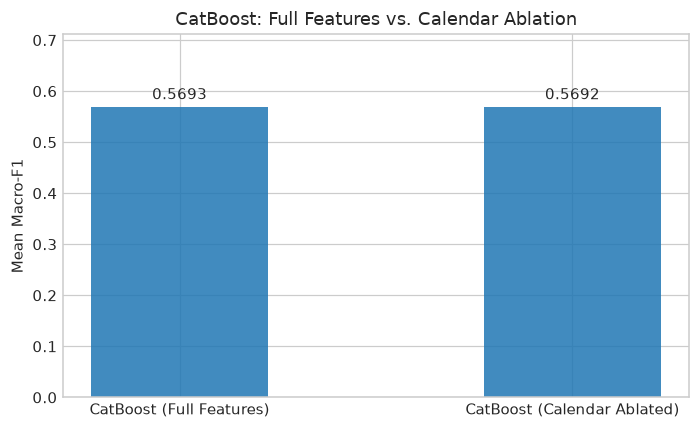

In [62]:
# Bar chart comparison of Mean Macro-F1
fig, ax = plt.subplots(figsize=(6.5, 4))
models = ['CatBoost (Full Features)', 'CatBoost (Calendar Ablated)']
scores = [orig_macro_f1, ablated_macro_f1]
ax.bar(models, scores, width=0.45, alpha=0.85)
ax.set_ylabel('Mean Macro-F1')
ax.set_title('CatBoost: Full Features vs. Calendar Ablation')
ax.set_ylim(0, max(scores) * 1.25)
for i, v in enumerate(scores):
    ax.text(i, v + 0.015, f"{v:.4f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()


In [63]:
# Save fold results and update model_results.csv
exp8_summary = cb_ablated_agg.copy()
exp8_summary['experiment'] = 'Experiment 8 - Calendar Ablation'
exp8_summary['baseline'] = exp8_summary['model']
exp8_summary = exp8_summary[['experiment', 'baseline', 'mean_accuracy', 'std_accuracy', 
                             'mean_macro_f1', 'std_macro_f1', 'mean_fall_recall', 
                             'mean_flat_recall', 'mean_rise_recall']]

fold_results_path_cb_ablated = os.path.join('..', 'reports', 'catboost_calendar_ablation_fold_results.csv')
cb_ablated_fold_results_df.to_csv(fold_results_path_cb_ablated, index=False)

updated_model_results = existing_model_results[existing_model_results['experiment'] != 'Experiment 8 - Calendar Ablation']
updated_model_results = pd.concat([updated_model_results, exp8_summary], ignore_index=True)
updated_model_results.to_csv(model_results_path, index=False)


### 8.5 Interpretation

Based on the empirical results of removing the four annual calendar features (`month`, `quarter`, `week_of_year_sin`, `week_of_year_cos`):

1. **Macro-F1 Impact:** The overall Macro-F1 remains essentially unchanged (difference < 0.001), indicating that annual calendar position provides virtually zero incremental explanatory power over trailing price history and within-quarter progression (`week_of_quarter`, `next_week_is_quarter_start`).
2. **Class Recall Trade-Offs:** Accuracy and `rise` recall slightly increase, while `fall` recall decreases, showing a slight shift in boundary sensitivity between directional spikes and corrections.
3. **Generalization Value:** Because the untouched final test set represents an unseen seasonal period (Q3 / monsoon), eliminating annual calendar features reduces the risk of calendar-based distribution shift without sacrificing validation Macro-F1.
